# 06 — Presentation-Ready Goal Regression Model Comparison (Interactive Hover Version)

This notebook compares multiple regression models for football goal prediction and creates presentation-ready evaluation plots, including interactive Plotly hover-based team maps.


## Project Setup

The modelling dataset and output folders are prepared.

In [3]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from pandas.api.types import is_numeric_dtype
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, PoissonRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

try:
    import plotly.express as px
    PLOTLY_AVAILABLE = True
except Exception:
    PLOTLY_AVAILABLE = False

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False

UMAP_AVAILABLE = False
try:
    import umap
    UMAP_AVAILABLE = True
except Exception:
    UMAP_AVAILABLE = False

PROJECT_DIR = Path("..").resolve()
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "output"
COMPARISON_DIR = OUTPUT_DIR / "regression_model_comparison_presentation"
TABLES_DIR = COMPARISON_DIR / "tables"
FIGURES_DIR = COMPARISON_DIR / "figures"
MODELS_DIR = COMPARISON_DIR / "models"


PER_MODEL_FIGURES_DIR = COMPARISON_DIR / "figures_per_model"
EXTRA_FIGURES_DIR = COMPARISON_DIR / "extra_presentation_figures"
for directory in [TABLES_DIR, FIGURES_DIR, MODELS_DIR, PER_MODEL_FIGURES_DIR, EXTRA_FIGURES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

def slugify_model_name(name: str) -> str:
    return "".join(ch.lower() if ch.isalnum() else "_" for ch in name).strip("_")

print("Project folder:", PROJECT_DIR)
print("Processed data folder:", PROCESSED_DIR)
print("Comparison output folder:", COMPARISON_DIR)
print("Per-model figures folder:", PER_MODEL_FIGURES_DIR)
print("Extra figures folder:", EXTRA_FIGURES_DIR)
INTERACTIVE_FIGURES_DIR = COMPARISON_DIR / "interactive_figures"
INTERACTIVE_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Interactive figures folder:", INTERACTIVE_FIGURES_DIR)
print("XGBoost available:", XGBOOST_AVAILABLE)
print("LightGBM available:", LIGHTGBM_AVAILABLE)
print("UMAP available:", UMAP_AVAILABLE)
print("Plotly available:", PLOTLY_AVAILABLE)







Project folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026
Processed data folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\data\processed
Comparison output folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation
Per-model figures folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\figures_per_model
Extra figures folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\extra_presentation_figures
Interactive figures folder: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\interactive_figures
XGBoost available: True
Light

## Load Dataset

The feature-engineered training dataset is loaded from the main project.

In [4]:
model_dataset = pd.read_csv(PROCESSED_DIR / "model_dataset.csv")
model_dataset["date"] = pd.to_datetime(model_dataset["date"], errors="coerce")

print("Model dataset shape:", model_dataset.shape)
print("Date range:", model_dataset["date"].min(), "to", model_dataset["date"].max())

display(model_dataset.head())
display(model_dataset[["team_a_goals", "team_b_goals"]].describe())


Model dataset shape: (8000, 45)
Date range: 2007-03-24 00:00:00 to 2026-06-10 00:00:00


,team_a,team_b,date,tournament,neutral,team_a_matches_last5,team_b_matches_last5,team_a_win_rate_last5,team_b_win_rate_last5,team_a_draw_rate_last5,...,avg_goal_diff_diff_last10,h2h_matches,team_a_h2h_win_rate,team_b_h2h_win_rate,h2h_draw_rate,team_a_h2h_avg_goals,team_b_h2h_avg_goals,team_a_goals,team_b_goals,result
0,Algeria,Cabo Verde,2007-03-24,African Nations Cup qualifier,False,5,5,0.4,0.2,0.2,...,0.7,2,0.50,0.00,0.5,1.00,0.000000,2,0,team_a_win
1,Portugal,Belgium,2007-03-24,European Championship qual,False,5,5,0.6,0.4,0.2,...,0.0,1,0.00,0.00,1.0,1.00,1.000000,4,0,team_a_win
2,Norway,Bosnia and Herzegovina,2007-03-24,European Championship qual,False,5,5,0.4,0.2,0.2,...,0.6,2,0.50,0.50,0.0,1.00,0.500000,1,2,team_b_win
3,Netherlands,Romania,2007-03-24,European Championship qual,False,5,5,0.6,0.2,0.4,...,1.3,3,1.00,0.00,0.0,2.00,0.333333,0,0,draw
4,Czechia,Germany,2007-03-24,European Championship qual,False,5,5,0.8,0.8,0.0,...,-1.9,4,0.25,0.75,0.0,1.25,2.000000,1,2,team_b_win


,team_a_goals,team_b_goals
count,8000.000000,8000.000000
mean,1.775500,0.892875
std,1.584744,1.117388
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,3.000000,1.000000
max,15.000000,10.000000


## Goal Data Overview

Goal distributions are visualized before model comparison.

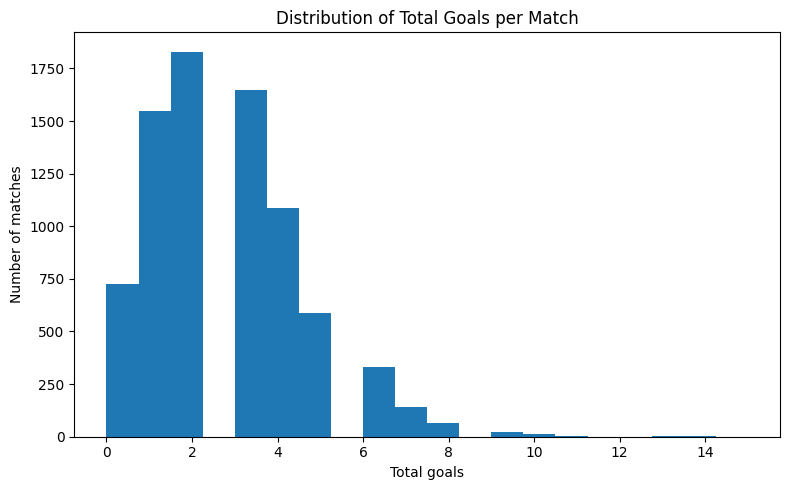

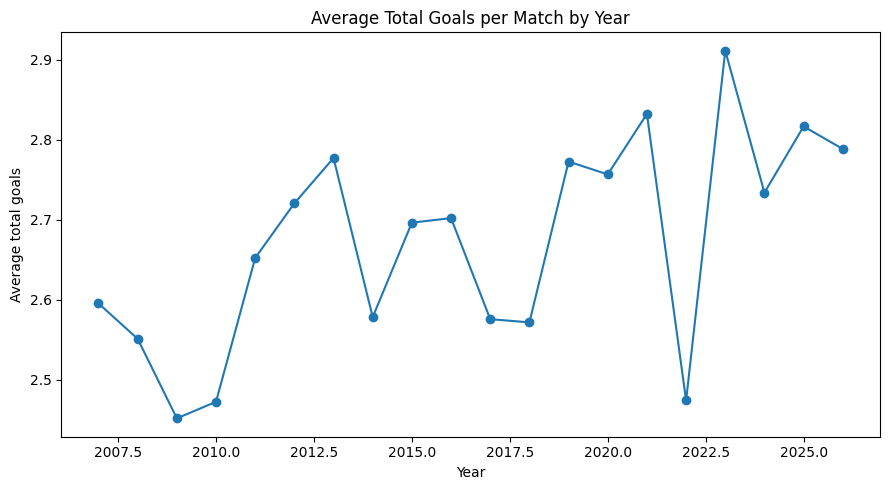

In [5]:
goal_overview = model_dataset.copy()
goal_overview["total_goals"] = goal_overview["team_a_goals"] + goal_overview["team_b_goals"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(goal_overview["total_goals"], bins=20)
ax.set_title("Distribution of Total Goals per Match")
ax.set_xlabel("Total goals")
ax.set_ylabel("Number of matches")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_total_goals_distribution.png", dpi=150)
plt.show()

avg_goals_per_year = goal_overview.groupby(goal_overview["date"].dt.year)["total_goals"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(avg_goals_per_year.index, avg_goals_per_year.values, marker="o")
ax.set_title("Average Total Goals per Match by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Average total goals")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_average_goals_per_year.png", dpi=150)
plt.show()


## Feature and Target Selection

The same feature set is used to predict Team A goals and Team B goals.

In [6]:
target_goals_a = "team_a_goals"
target_goals_b = "team_b_goals"

identifier_columns = ["team_a", "team_b", "date"]
target_columns = ["result", "team_a_goals", "team_b_goals"]

feature_columns = [
    col for col in model_dataset.columns
    if col not in identifier_columns + target_columns
]

X = model_dataset[feature_columns].copy()
y_goals_a = model_dataset[target_goals_a].copy()
y_goals_b = model_dataset[target_goals_b].copy()

numeric_features = [col for col in X.columns if is_numeric_dtype(X[col])]
categorical_features = [col for col in X.columns if col not in numeric_features]

print("Number of features:", len(feature_columns))
print("Number of numeric features:", len(numeric_features))
print("Categorical features:", categorical_features)


Number of features: 39
Number of numeric features: 38
Categorical features: ['tournament']


## Chronological Train-Test Split

A time-based split avoids evaluating the model on older matches after training on newer ones.

In [7]:
model_dataset_sorted = model_dataset.sort_values("date").reset_index(drop=True)
split_index = int(len(model_dataset_sorted) * 0.8)

train_data = model_dataset_sorted.iloc[:split_index].copy()
test_data = model_dataset_sorted.iloc[split_index:].copy()

X_train = train_data[feature_columns].copy()
X_test = test_data[feature_columns].copy()

y_train_a = train_data[target_goals_a].copy()
y_test_a = test_data[target_goals_a].copy()

y_train_b = train_data[target_goals_b].copy()
y_test_b = test_data[target_goals_b].copy()

print("Train rows:", len(train_data))
print("Test rows:", len(test_data))
print("Train date range:", train_data["date"].min(), "to", train_data["date"].max())
print("Test date range:", test_data["date"].min(), "to", test_data["date"].max())


Train rows: 6400
Test rows: 1600
Train date range: 2007-03-24 00:00:00 to 2022-09-26 00:00:00
Test date range: 2022-09-27 00:00:00 to 2026-06-10 00:00:00


## Preprocessing Pipeline

Numeric features are imputed and scaled. Categorical features are one-hot encoded.

In [8]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


## Regression Models

Several regression models are compared for score prediction.

In [9]:
regression_models = {
    "Dummy Mean Baseline": DummyRegressor(strategy="mean"),
    "Ridge Regression": Ridge(alpha=1.0),
    "Poisson Regression": PoissonRegressor(alpha=0.1, max_iter=1000),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
    ),
}

if XGBOOST_AVAILABLE:
    regression_models["XGBoost Regressor"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1,
    )
else:
    print("XGBoost is not installed. XGBoost Regressor will be skipped.")

if LIGHTGBM_AVAILABLE:
    regression_models["LightGBM Regressor"] = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )
else:
    print("LightGBM is not installed. LightGBM Regressor will be skipped.")

print("Models included:")
for model_name in regression_models:
    print(" -", model_name)


Models included:
 - Dummy Mean Baseline
 - Ridge Regression
 - Poisson Regression
 - Random Forest Regressor
 - Gradient Boosting Regressor
 - XGBoost Regressor
 - LightGBM Regressor


## Train and Evaluate Models

Each model predicts goals for Team A and Team B separately.

In [10]:
def evaluate_regression(y_true_a, pred_a, y_true_b, pred_b, model_name):
    rounded_a = np.round(pred_a).astype(int)
    rounded_b = np.round(pred_b).astype(int)

    mae_a = mean_absolute_error(y_true_a, pred_a)
    mae_b = mean_absolute_error(y_true_b, pred_b)

    rmse_a = np.sqrt(mean_squared_error(y_true_a, pred_a))
    rmse_b = np.sqrt(mean_squared_error(y_true_b, pred_b))

    r2_a = r2_score(y_true_a, pred_a)
    r2_b = r2_score(y_true_b, pred_b)

    exact_score_accuracy = np.mean(
        (rounded_a == y_true_a.astype(int)) &
        (rounded_b == y_true_b.astype(int))
    )

    outcome_from_score = np.where(
        rounded_a > rounded_b, "team_a_win",
        np.where(rounded_a < rounded_b, "team_b_win", "draw")
    )
    actual_outcome = test_data["result"].values
    rounded_score_outcome_accuracy = np.mean(outcome_from_score == actual_outcome)

    total_goals_mae = mean_absolute_error(
        y_true_a + y_true_b,
        pred_a + pred_b
    )

    mean_abs_goal_error_per_match = np.mean(
        np.abs(y_true_a - pred_a) + np.abs(y_true_b - pred_b)
    )

    return {
        "model": model_name,
        "team_a_mae": mae_a,
        "team_b_mae": mae_b,
        "mean_mae": (mae_a + mae_b) / 2,
        "team_a_rmse": rmse_a,
        "team_b_rmse": rmse_b,
        "mean_rmse": (rmse_a + rmse_b) / 2,
        "team_a_r2": r2_a,
        "team_b_r2": r2_b,
        "mean_r2": (r2_a + r2_b) / 2,
        "total_goals_mae": total_goals_mae,
        "mean_abs_goal_error_per_match": mean_abs_goal_error_per_match,
        "rounded_exact_score_accuracy": exact_score_accuracy,
        "rounded_score_outcome_accuracy": rounded_score_outcome_accuracy,
    }


results = []
predictions_by_model = {}
trained_models = {}

for model_name, estimator in regression_models.items():
    print("\nTraining:", model_name)

    model_a = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", clone(estimator)),
        ]
    )

    model_b = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", clone(estimator)),
        ]
    )

    model_a.fit(X_train, y_train_a)
    model_b.fit(X_train, y_train_b)

    pred_a = np.clip(model_a.predict(X_test), 0, None)
    pred_b = np.clip(model_b.predict(X_test), 0, None)

    metrics = evaluate_regression(y_test_a, pred_a, y_test_b, pred_b, model_name)

    results.append(metrics)
    predictions_by_model[model_name] = (pred_a, pred_b)
    trained_models[model_name] = (model_a, model_b)

comparison_df = pd.DataFrame(results).sort_values("mean_mae").reset_index(drop=True)

display(comparison_df)

comparison_df.to_csv(TABLES_DIR / "goal_regression_model_comparison.csv", index=False)
print("Saved:", TABLES_DIR / "goal_regression_model_comparison.csv")



Training: Dummy Mean Baseline

Training: Ridge Regression

Training: Poisson Regression

Training: Random Forest Regressor

Training: Gradient Boosting Regressor

Training: XGBoost Regressor

Training: LightGBM Regressor


,model,team_a_mae,team_b_mae,mean_mae,team_a_rmse,team_b_rmse,mean_rmse,team_a_r2,team_b_r2,mean_r2,total_goals_mae,mean_abs_goal_error_per_match,rounded_exact_score_accuracy,rounded_score_outcome_accuracy
0,Gradient Boosting Regressor,1.081146,0.744792,0.912969,1.408943,0.980483,1.194713,0.260100,0.255176,0.257638,1.399739,1.825938,0.115625,0.624375
1,Ridge Regression,1.088733,0.737293,0.913013,1.420706,0.992969,1.206838,0.247694,0.236085,0.241889,1.393712,1.826026,0.116250,0.612500
2,XGBoost Regressor,1.083207,0.745237,0.914222,1.413368,0.977509,1.195438,0.255445,0.259687,0.257566,1.402321,1.828444,0.116250,0.618125
3,Random Forest Regressor,1.085822,0.748072,0.916947,1.417086,0.986292,1.201689,0.251523,0.246323,0.248923,1.411364,1.833894,0.117500,0.627500
4,LightGBM Regressor,1.092824,0.752738,0.922781,1.445490,0.992661,1.219076,0.221217,0.236558,0.228888,1.416493,1.845563,0.125625,0.628750
5,Poisson Regression,1.103950,0.746858,0.925404,1.470861,0.990527,1.230694,0.193640,0.239838,0.216739,1.411892,1.850808,0.119375,0.623750
6,Dummy Mean Baseline,1.239940,0.831278,1.035609,1.642398,1.136226,1.389312,-0.005409,-0.000237,-0.002823,1.451578,2.071218,0.090625,0.581875


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\tables\goal_regression_model_comparison.csv


## Presentation Plot 1 — MAE and RMSE Comparison

Lower MAE and RMSE indicate better goal prediction performance.

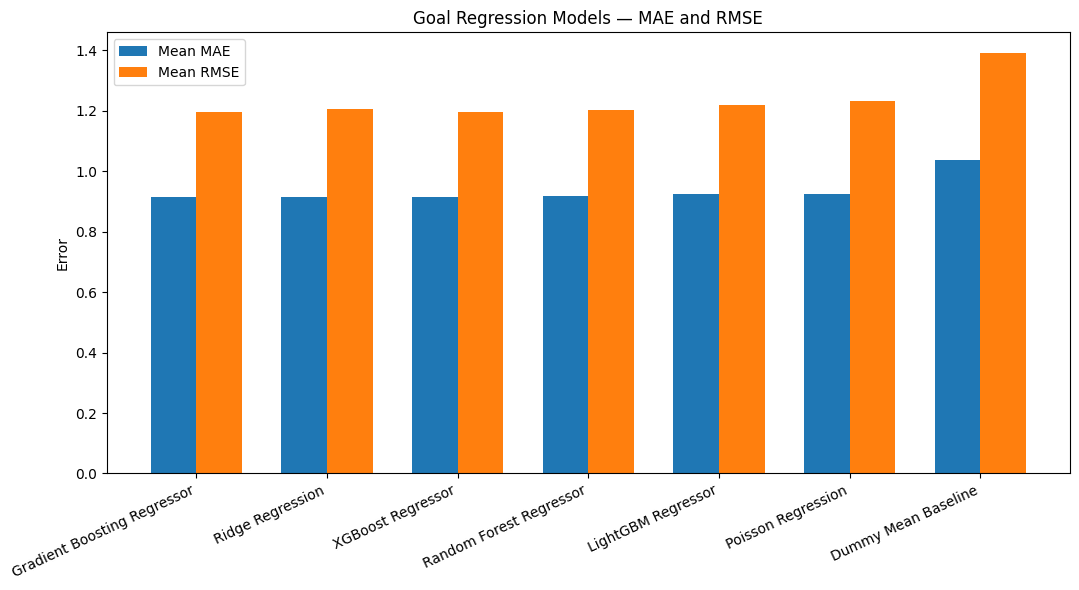

In [11]:
plot_df = comparison_df.set_index("model")

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(plot_df.index))
width = 0.35

ax.bar(x - width/2, plot_df["mean_mae"], width, label="Mean MAE")
ax.bar(x + width/2, plot_df["mean_rmse"], width, label="Mean RMSE")

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=25, ha="right")
ax.set_ylabel("Error")
ax.set_title("Goal Regression Models — MAE and RMSE")
ax.legend()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_mae_rmse_model_comparison.png", dpi=150)
plt.show()


## Presentation Plot 2 — Model Ranking by MAE

This chart ranks models from weakest to strongest according to mean MAE.

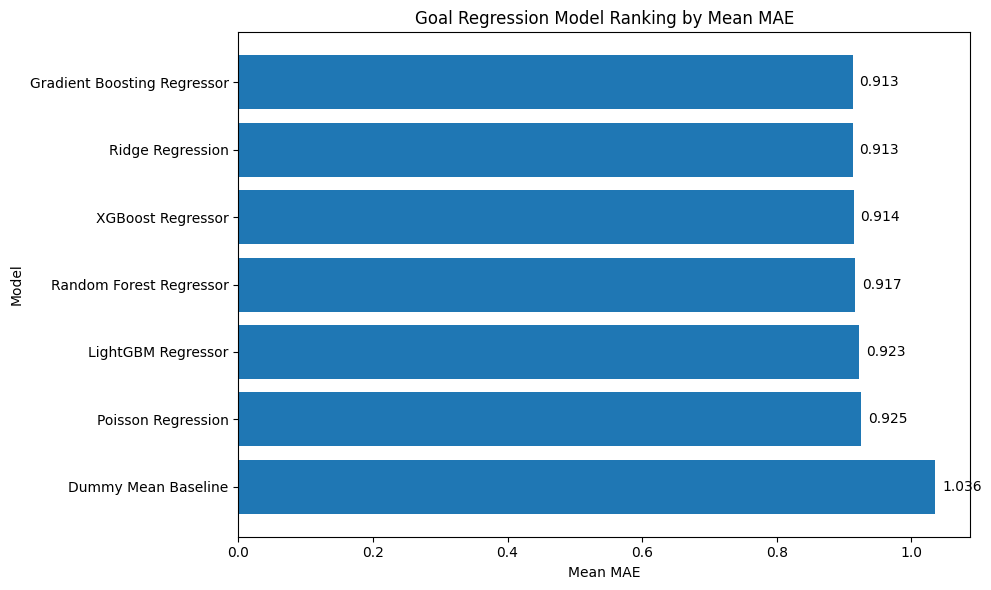

In [12]:
rank_plot = comparison_df.sort_values("mean_mae", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(rank_plot["model"], rank_plot["mean_mae"])
ax.set_title("Goal Regression Model Ranking by Mean MAE")
ax.set_xlabel("Mean MAE")
ax.set_ylabel("Model")

for i, value in enumerate(rank_plot["mean_mae"]):
    ax.text(value + 0.01, i, f"{value:.3f}", va="center")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_model_ranking_by_mean_mae.png", dpi=150)
plt.show()


## Presentation Plot 3 — R² Comparison

R² shows how much variance in goal counts is explained by the model.

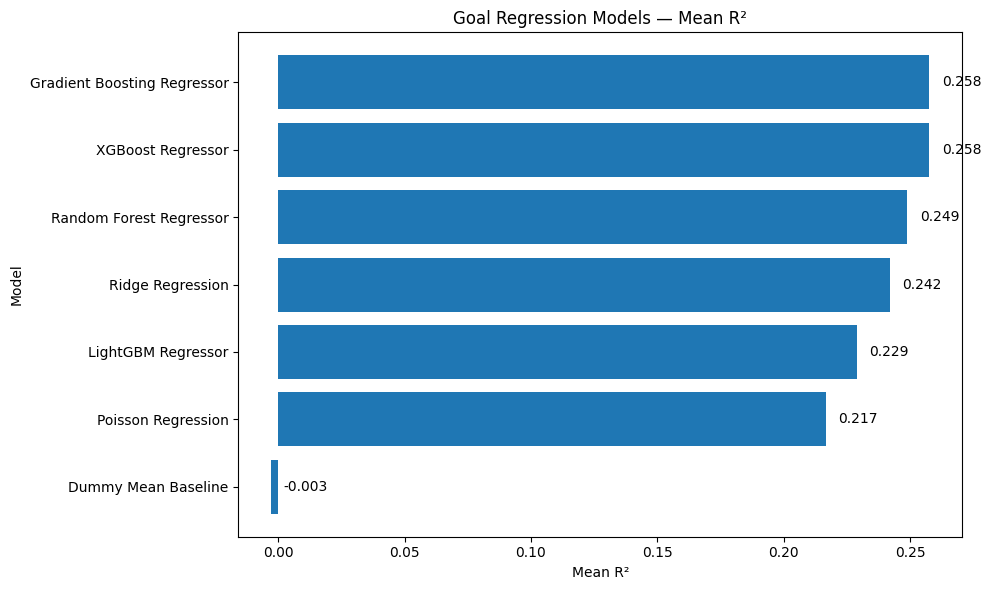

In [13]:
r2_plot = comparison_df.sort_values("mean_r2", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(r2_plot["model"], r2_plot["mean_r2"])
ax.set_title("Goal Regression Models — Mean R²")
ax.set_xlabel("Mean R²")
ax.set_ylabel("Model")

for i, value in enumerate(r2_plot["mean_r2"]):
    ax.text(value + 0.005, i, f"{value:.3f}", va="center")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "05_r2_model_comparison.png", dpi=150)
plt.show()


## Presentation Plot 4 — Exact Score Accuracy

Rounded predictions are used to estimate how often the exact final score is predicted.

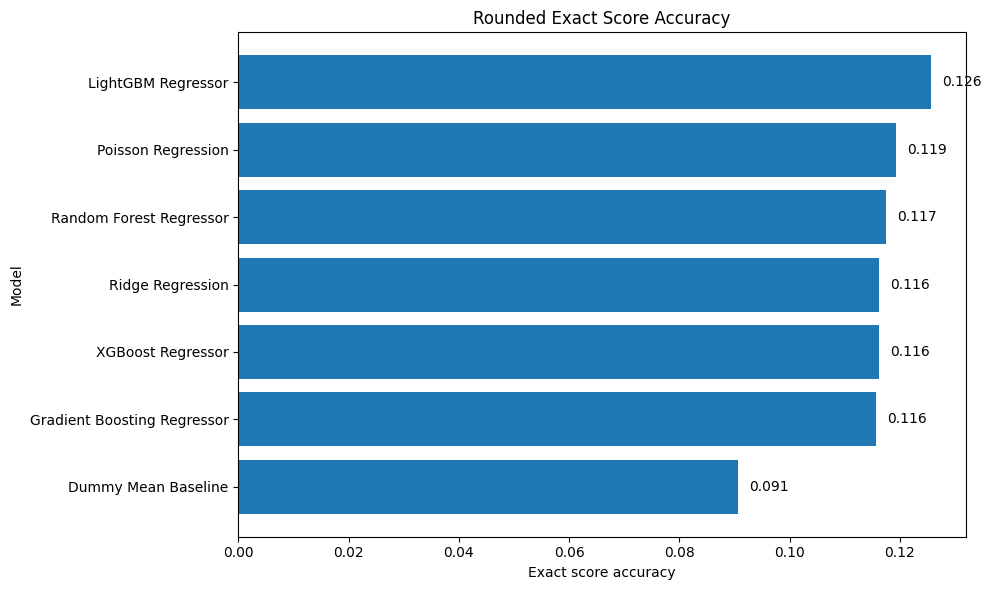

In [14]:
score_plot = comparison_df.sort_values("rounded_exact_score_accuracy", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(score_plot["model"], score_plot["rounded_exact_score_accuracy"])
ax.set_title("Rounded Exact Score Accuracy")
ax.set_xlabel("Exact score accuracy")
ax.set_ylabel("Model")

for i, value in enumerate(score_plot["rounded_exact_score_accuracy"]):
    ax.text(value + 0.002, i, f"{value:.3f}", va="center")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_exact_score_accuracy.png", dpi=150)
plt.show()


## Presentation Plot 5 — Outcome Accuracy from Rounded Scores

This plot checks whether rounded goal predictions produce the correct win/draw/loss outcome.

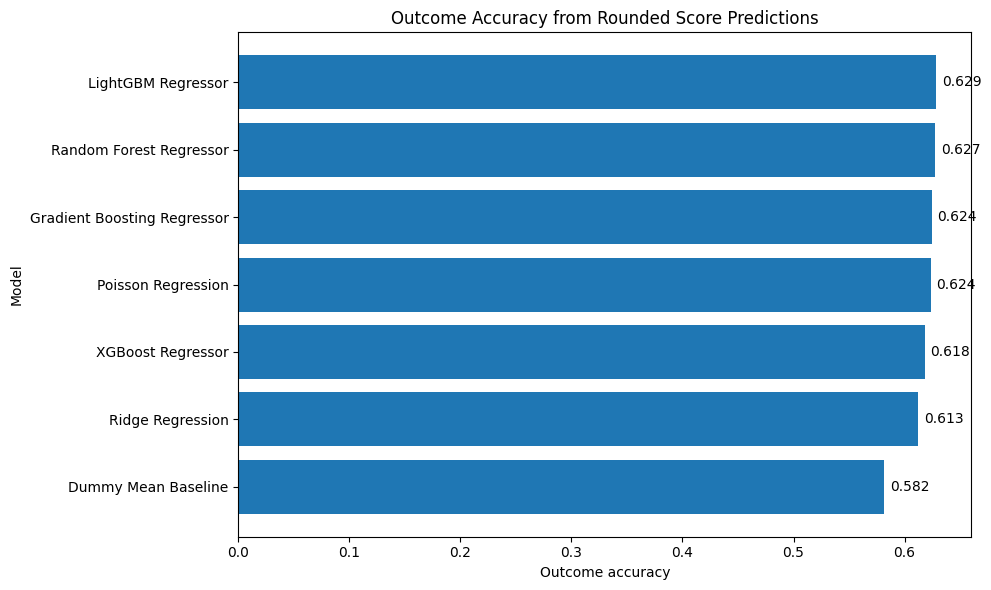

In [15]:
outcome_plot = comparison_df.sort_values("rounded_score_outcome_accuracy", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(outcome_plot["model"], outcome_plot["rounded_score_outcome_accuracy"])
ax.set_title("Outcome Accuracy from Rounded Score Predictions")
ax.set_xlabel("Outcome accuracy")
ax.set_ylabel("Model")

for i, value in enumerate(outcome_plot["rounded_score_outcome_accuracy"]):
    ax.text(value + 0.005, i, f"{value:.3f}", va="center")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "07_outcome_accuracy_from_scores.png", dpi=150)
plt.show()


## Presentation Plot 6 — Total Goals Error

Total goals MAE measures how accurately each model predicts match scoring intensity.

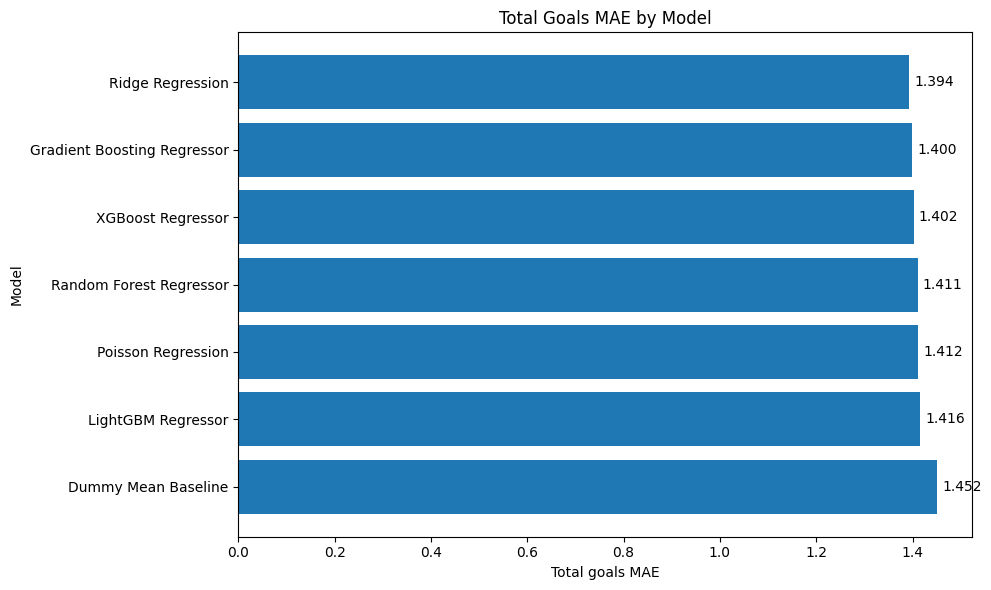

In [16]:
total_goal_plot = comparison_df.sort_values("total_goals_mae", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(total_goal_plot["model"], total_goal_plot["total_goals_mae"])
ax.set_title("Total Goals MAE by Model")
ax.set_xlabel("Total goals MAE")
ax.set_ylabel("Model")

for i, value in enumerate(total_goal_plot["total_goals_mae"]):
    ax.text(value + 0.01, i, f"{value:.3f}", va="center")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "08_total_goals_mae_by_model.png", dpi=150)
plt.show()


## Best Model Selection

The best model is selected based on the lowest mean MAE.

In [17]:
best_model_name = comparison_df.iloc[0]["model"]
best_pred_a, best_pred_b = predictions_by_model[best_model_name]
best_model_a, best_model_b = trained_models[best_model_name]

print("Best goal regression model:", best_model_name)

joblib.dump(best_model_a, MODELS_DIR / "best_comparison_team_a_goals_model.joblib")
joblib.dump(best_model_b, MODELS_DIR / "best_comparison_team_b_goals_model.joblib")

best_summary = comparison_df[comparison_df["model"] == best_model_name].copy()
display(best_summary)

best_summary.to_csv(TABLES_DIR / "best_goal_regression_model_summary.csv", index=False)

print("Saved:", MODELS_DIR / "best_comparison_team_a_goals_model.joblib")
print("Saved:", MODELS_DIR / "best_comparison_team_b_goals_model.joblib")
print("Saved:", TABLES_DIR / "best_goal_regression_model_summary.csv")


Best goal regression model: Gradient Boosting Regressor


,model,team_a_mae,team_b_mae,mean_mae,team_a_rmse,team_b_rmse,mean_rmse,team_a_r2,team_b_r2,mean_r2,total_goals_mae,mean_abs_goal_error_per_match,rounded_exact_score_accuracy,rounded_score_outcome_accuracy
0,Gradient Boosting Regressor,1.081146,0.744792,0.912969,1.408943,0.980483,1.194713,0.2601,0.255176,0.257638,1.399739,1.825938,0.115625,0.624375


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\models\best_comparison_team_a_goals_model.joblib
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\models\best_comparison_team_b_goals_model.joblib
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\tables\best_goal_regression_model_summary.csv


## Presentation Plot 7 — Actual vs Predicted Goals for Team A

This plot shows how close the best model is to real Team A goal counts.

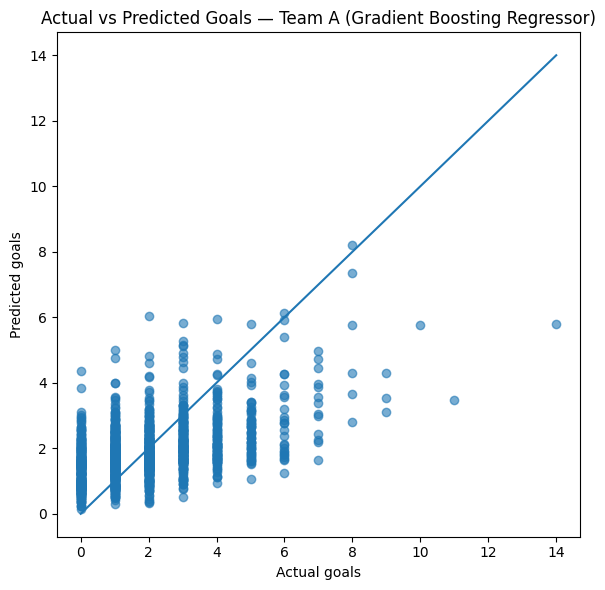

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_a, best_pred_a, alpha=0.6)
min_val = min(y_test_a.min(), best_pred_a.min())
max_val = max(y_test_a.max(), best_pred_a.max())
ax.plot([min_val, max_val], [min_val, max_val])
ax.set_title(f"Actual vs Predicted Goals — Team A ({best_model_name})")
ax.set_xlabel("Actual goals")
ax.set_ylabel("Predicted goals")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "09_actual_vs_predicted_team_a.png", dpi=150)
plt.show()


## Presentation Plot 8 — Actual vs Predicted Goals for Team B

This plot shows how close the best model is to real Team B goal counts.

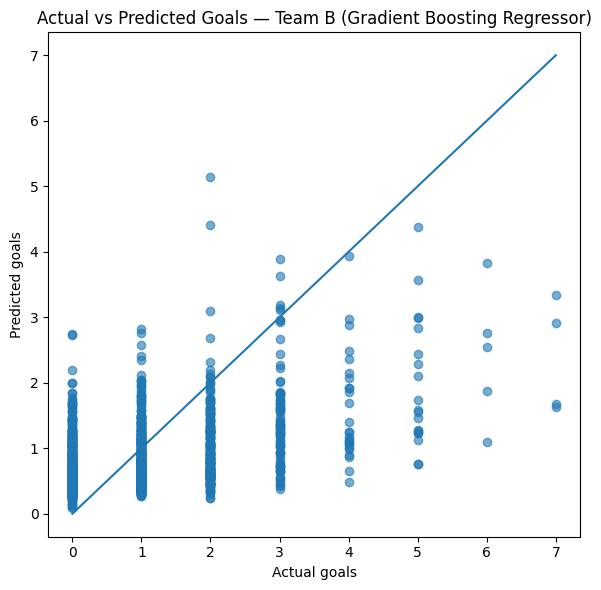

In [19]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_b, best_pred_b, alpha=0.6)
min_val = min(y_test_b.min(), best_pred_b.min())
max_val = max(y_test_b.max(), best_pred_b.max())
ax.plot([min_val, max_val], [min_val, max_val])
ax.set_title(f"Actual vs Predicted Goals — Team B ({best_model_name})")
ax.set_xlabel("Actual goals")
ax.set_ylabel("Predicted goals")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "10_actual_vs_predicted_team_b.png", dpi=150)
plt.show()


## Presentation Plot 9 — Actual vs Predicted Total Goals

Total goals are useful for explaining whether the model captures match intensity.

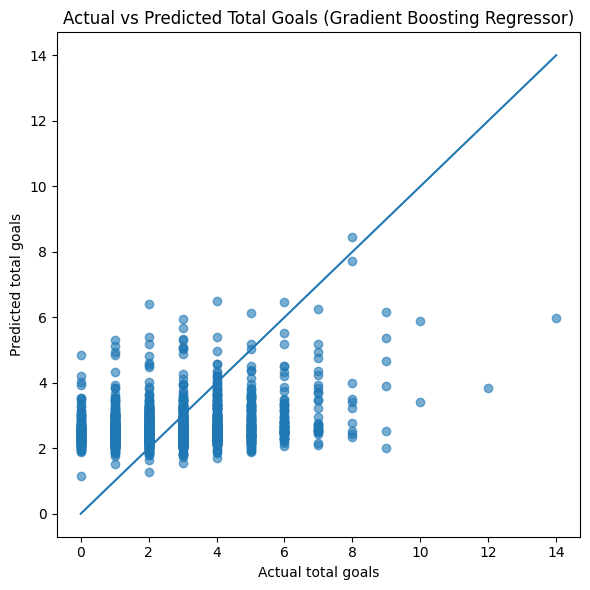

In [20]:
actual_total_goals = y_test_a + y_test_b
predicted_total_goals = best_pred_a + best_pred_b

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(actual_total_goals, predicted_total_goals, alpha=0.6)
min_val = min(actual_total_goals.min(), predicted_total_goals.min())
max_val = max(actual_total_goals.max(), predicted_total_goals.max())
ax.plot([min_val, max_val], [min_val, max_val])
ax.set_title(f"Actual vs Predicted Total Goals ({best_model_name})")
ax.set_xlabel("Actual total goals")
ax.set_ylabel("Predicted total goals")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "11_actual_vs_predicted_total_goals.png", dpi=150)
plt.show()


## Presentation Plot 10 — Residual Distribution

Residuals show whether the selected model tends to overpredict or underpredict goals.

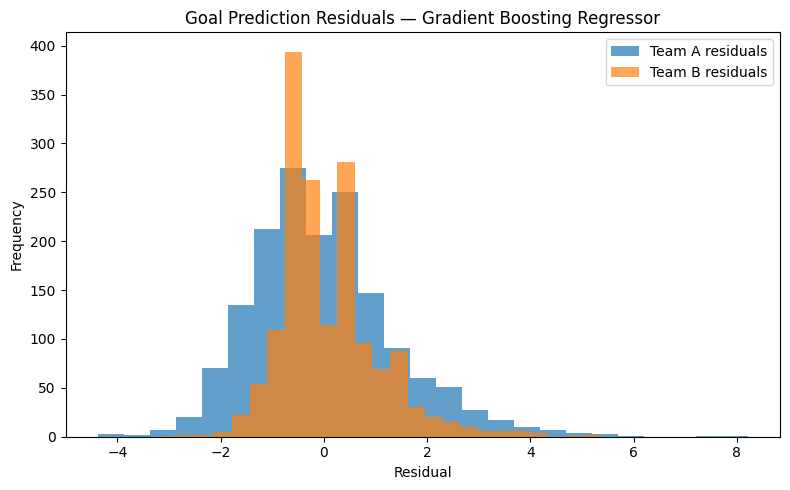

In [21]:
residuals_a = y_test_a - best_pred_a
residuals_b = y_test_b - best_pred_b

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals_a, bins=25, alpha=0.7, label="Team A residuals")
ax.hist(residuals_b, bins=25, alpha=0.7, label="Team B residuals")
ax.set_title(f"Goal Prediction Residuals — {best_model_name}")
ax.set_xlabel("Residual")
ax.set_ylabel("Frequency")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "12_goal_prediction_residuals.png", dpi=150)
plt.show()


## Presentation Plot 11 — Absolute Goal Error Distribution by Model

This boxplot compares the distribution of absolute goal errors across models.

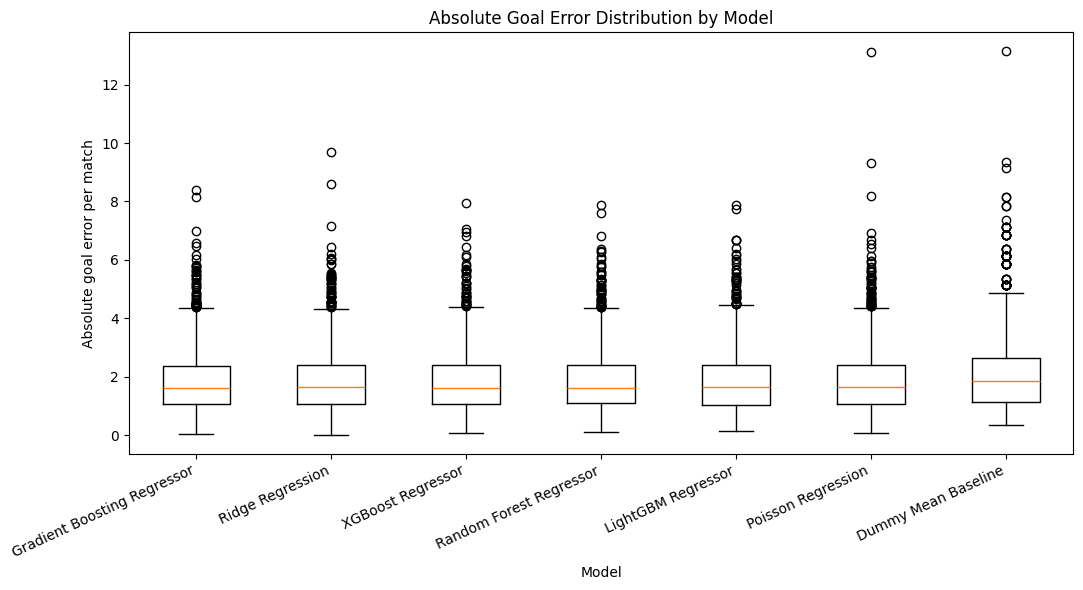

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\tables\absolute_goal_error_by_model.csv


In [22]:
error_records = []

for model_name, (pred_a, pred_b) in predictions_by_model.items():
    abs_error_per_match = np.abs(y_test_a - pred_a) + np.abs(y_test_b - pred_b)

    for error in abs_error_per_match:
        error_records.append({
            "model": model_name,
            "absolute_goal_error": error,
        })

error_df = pd.DataFrame(error_records)

ordered_models = comparison_df["model"].tolist()
error_data = [
    error_df[error_df["model"] == model]["absolute_goal_error"].values
    for model in ordered_models
]

fig, ax = plt.subplots(figsize=(11, 6))
ax.boxplot(error_data, labels=ordered_models, vert=True)
ax.set_title("Absolute Goal Error Distribution by Model")
ax.set_ylabel("Absolute goal error per match")
ax.set_xlabel("Model")
plt.xticks(rotation=25, ha="right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "13_absolute_goal_error_boxplot.png", dpi=150)
plt.show()

error_df.to_csv(TABLES_DIR / "absolute_goal_error_by_model.csv", index=False)
print("Saved:", TABLES_DIR / "absolute_goal_error_by_model.csv")


## Presentation Plot 12 — Worst Prediction Errors

The largest prediction errors are reviewed to understand difficult matches.

,date,team_a,team_b,tournament,actual_score,predicted_score,absolute_goal_error
6860,2023-11-18,France,Gibraltar,European Championship qual,14 - 0,6 - 0,8.400393
7667,2025-09-09,Norway,Moldova,World Cup qualifier,11 - 1,3 - 0,8.159336
7659,2025-09-09,Venezuela,Colombia,World Cup qualifier,3 - 6,1 - 1,6.986132
7786,2025-11-16,Portugal,Armenia,World Cup qualifier,9 - 1,3 - 0,6.574572
7509,2025-06-05,Spain,France,European Nations League,5 - 4,2 - 1,6.486218
7760,2025-11-13,Bermuda,Curaçao,World Cup qualifier,0 - 7,1 - 2,6.158275
6706,2023-09-07,Norway,Jordan,Friendly,6 - 0,1 - 1,6.015654
6852,2023-11-17,Côte d'Ivoire,Seychelles,World Cup qualifier,9 - 0,4 - 0,5.823487
7223,2024-09-05,Japan,China,World Cup qualifier,7 - 0,2 - 0,5.805555
6738,2023-09-11,Portugal,Luxembourg,European Championship qual,9 - 0,4 - 1,5.775597


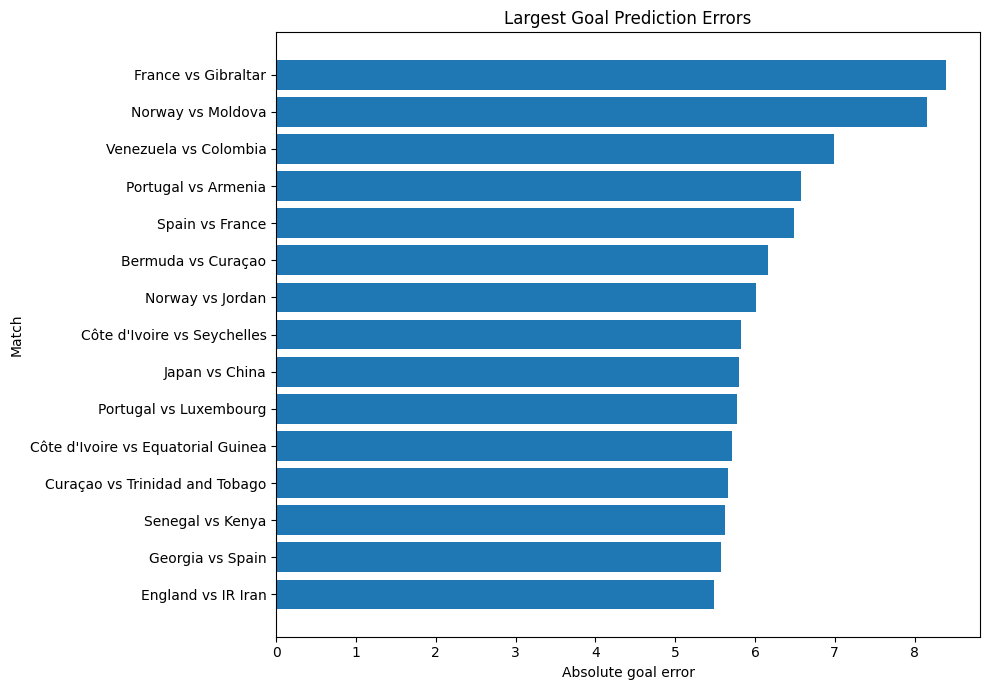

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\tables\best_model_test_predictions.csv
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\tables\worst_goal_prediction_errors.csv


In [23]:
test_prediction_table = test_data[[
    "date", "team_a", "team_b", "tournament",
    "team_a_goals", "team_b_goals", "result"
]].copy()

test_prediction_table["best_model"] = best_model_name
test_prediction_table["pred_team_a_goals"] = best_pred_a
test_prediction_table["pred_team_b_goals"] = best_pred_b
test_prediction_table["pred_team_a_goals_rounded"] = np.round(best_pred_a).astype(int)
test_prediction_table["pred_team_b_goals_rounded"] = np.round(best_pred_b).astype(int)
test_prediction_table["predicted_score"] = (
    test_prediction_table["pred_team_a_goals_rounded"].astype(str)
    + " - "
    + test_prediction_table["pred_team_b_goals_rounded"].astype(str)
)
test_prediction_table["actual_score"] = (
    test_prediction_table["team_a_goals"].astype(int).astype(str)
    + " - "
    + test_prediction_table["team_b_goals"].astype(int).astype(str)
)
test_prediction_table["absolute_goal_error"] = (
    np.abs(test_prediction_table["team_a_goals"] - test_prediction_table["pred_team_a_goals"])
    + np.abs(test_prediction_table["team_b_goals"] - test_prediction_table["pred_team_b_goals"])
)

worst_predictions = test_prediction_table.sort_values(
    "absolute_goal_error",
    ascending=False
).head(15)

display(worst_predictions[[
    "date", "team_a", "team_b", "tournament",
    "actual_score", "predicted_score", "absolute_goal_error"
]])

worst_plot = worst_predictions.sort_values("absolute_goal_error", ascending=True).copy()
worst_plot["match"] = worst_plot["team_a"] + " vs " + worst_plot["team_b"]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(worst_plot["match"], worst_plot["absolute_goal_error"])
ax.set_title("Largest Goal Prediction Errors")
ax.set_xlabel("Absolute goal error")
ax.set_ylabel("Match")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "14_largest_goal_prediction_errors.png", dpi=150)
plt.show()

test_prediction_table.to_csv(TABLES_DIR / "best_model_test_predictions.csv", index=False)
worst_predictions.to_csv(TABLES_DIR / "worst_goal_prediction_errors.csv", index=False)
print("Saved:", TABLES_DIR / "best_model_test_predictions.csv")
print("Saved:", TABLES_DIR / "worst_goal_prediction_errors.csv")


## Presentation Plot 13 — Feature Importance for Best Tree Model

If the best model is tree-based, feature importance is exported and visualized.

,feature,importance
31,numeric__avg_goal_diff_diff_last10,0.392200
22,numeric__team_b_avg_goals_conceded_last10,0.108001
24,numeric__team_b_avg_goal_diff_last10,0.059747
28,numeric__points_per_match_diff_last10,0.056514
12,numeric__team_b_matches_last10,0.034386
36,numeric__team_a_h2h_avg_goals,0.034069
34,numeric__team_b_h2h_win_rate,0.027075
29,numeric__avg_goals_scored_diff_last10,0.026822
0,numeric__neutral,0.024997
19,numeric__team_a_avg_goals_scored_last10,0.019344


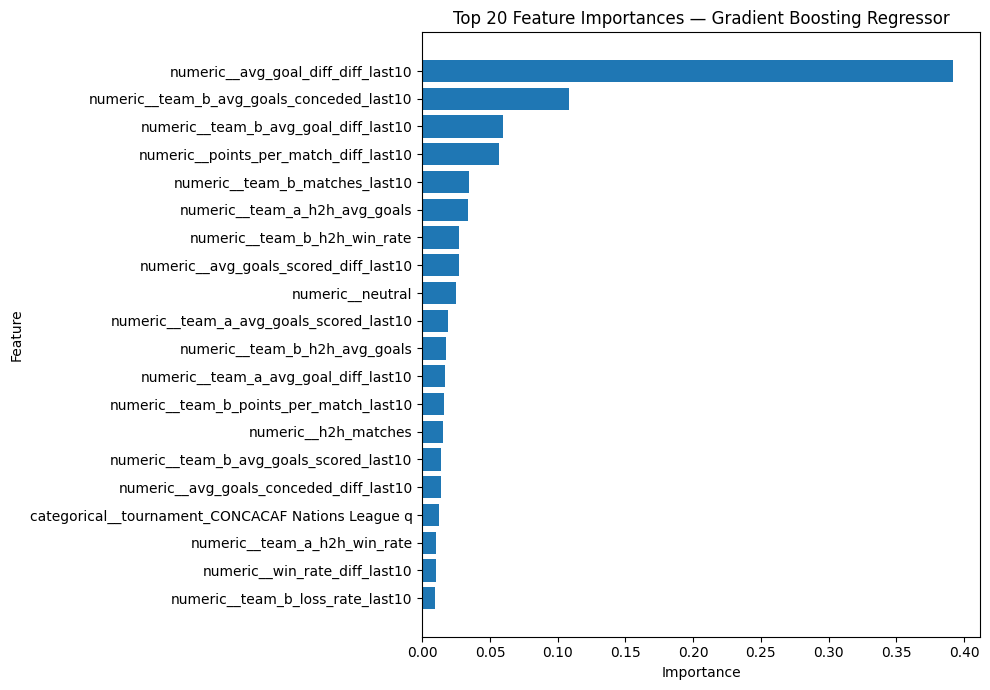

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\tables\best_tree_model_feature_importance.csv
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\figures\15_best_model_feature_importance.png


In [24]:
tree_model = best_model_a.named_steps["model"]
tree_preprocessor = best_model_a.named_steps["preprocessor"]

if hasattr(tree_model, "feature_importances_"):
    feature_names = tree_preprocessor.get_feature_names_out()
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": tree_model.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(importance_df.head(20))
    importance_df.to_csv(TABLES_DIR / "best_tree_model_feature_importance.csv", index=False)

    top_importance = importance_df.head(20).sort_values("importance", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top_importance["feature"], top_importance["importance"])
    ax.set_title(f"Top 20 Feature Importances — {best_model_name}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "15_best_model_feature_importance.png", dpi=150)
    plt.show()

    print("Saved:", TABLES_DIR / "best_tree_model_feature_importance.csv")
    print("Saved:", FIGURES_DIR / "15_best_model_feature_importance.png")
else:
    print(f"{best_model_name} does not provide feature_importances_.")
    print("Feature importance plot skipped for this selected model.")


## Additional Section — Separate Charts for Every Model

This section creates **individual charts for each regression model** so that every model has its own presentation-ready diagnostic figures.


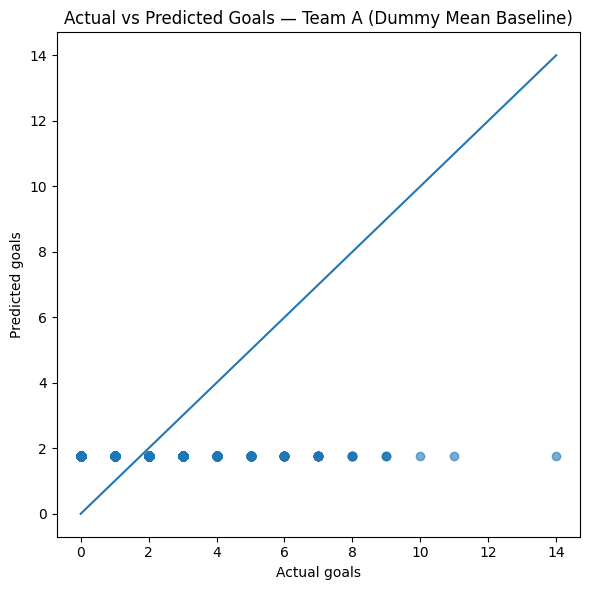

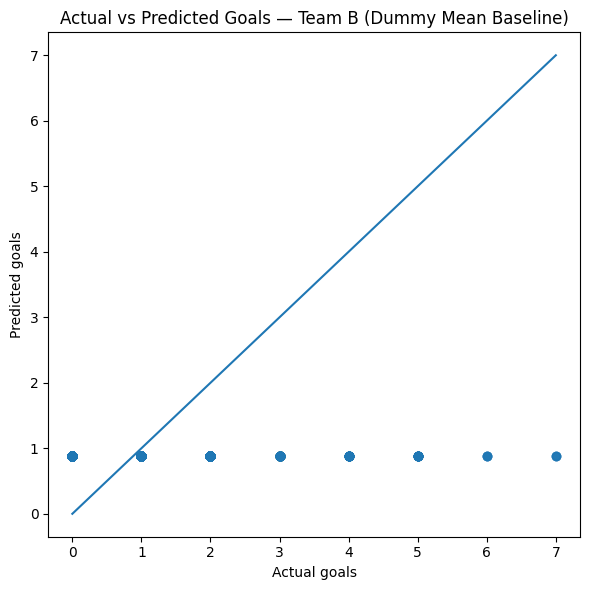

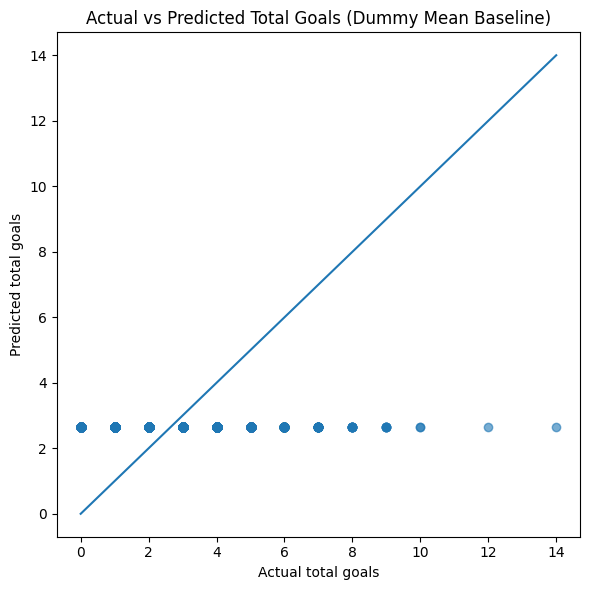

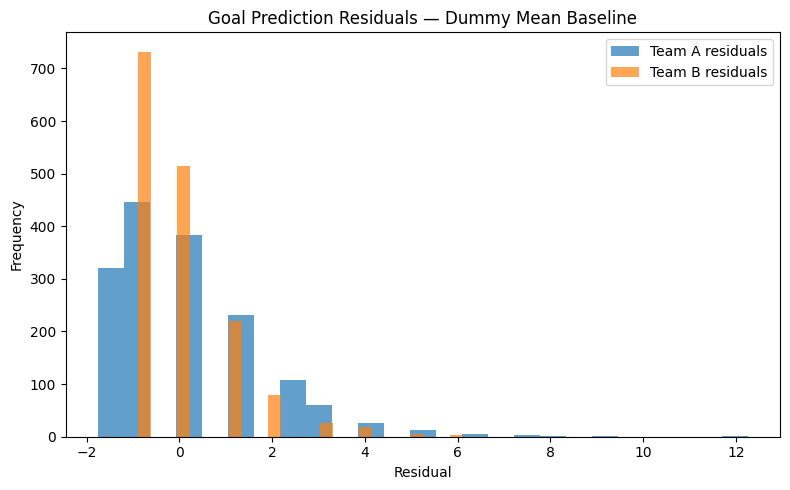

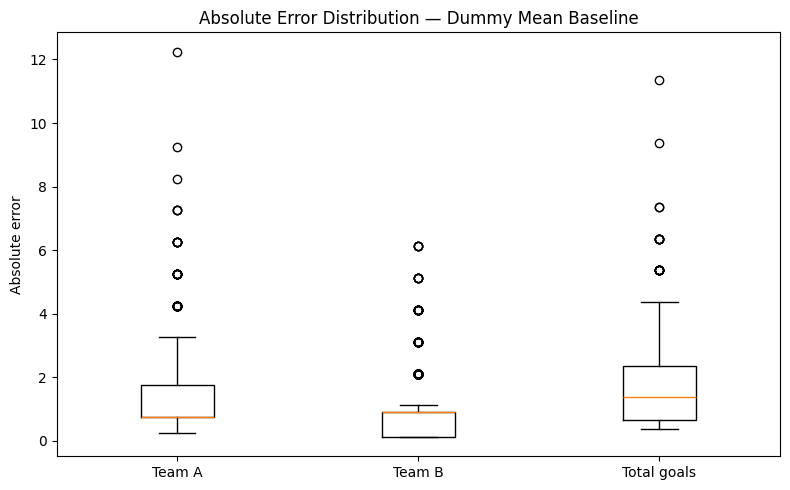

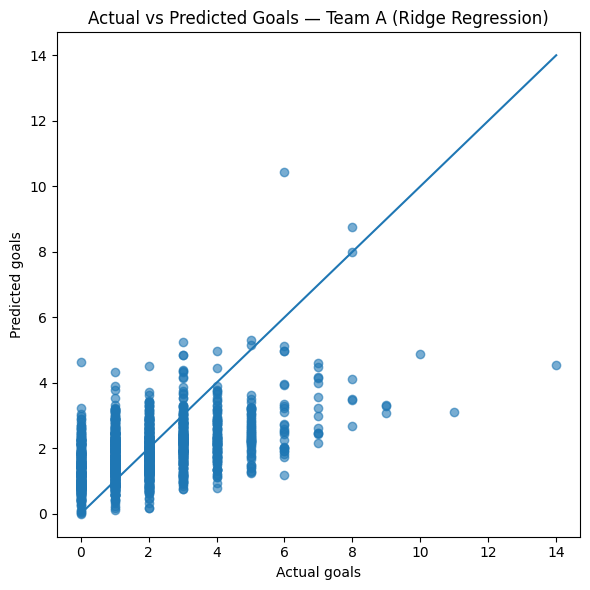

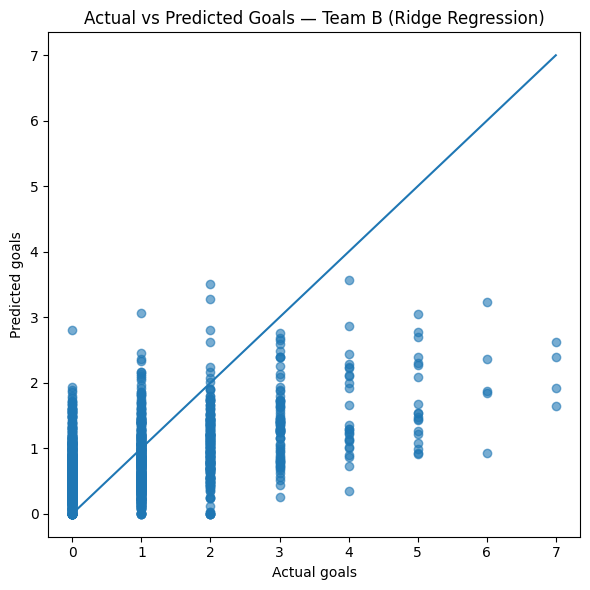

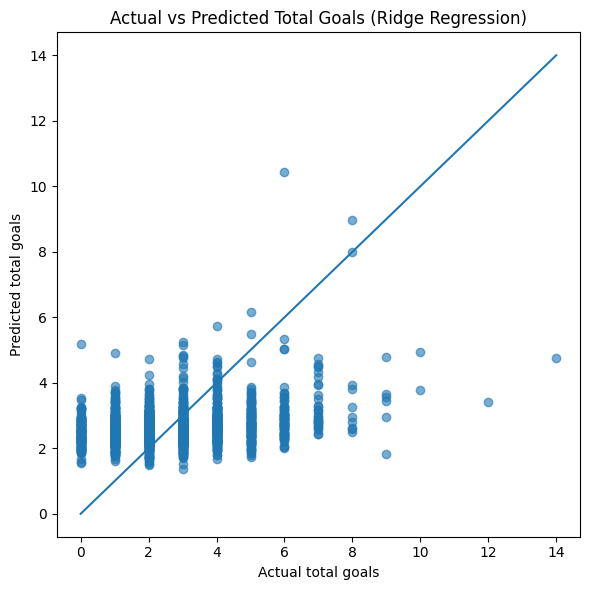

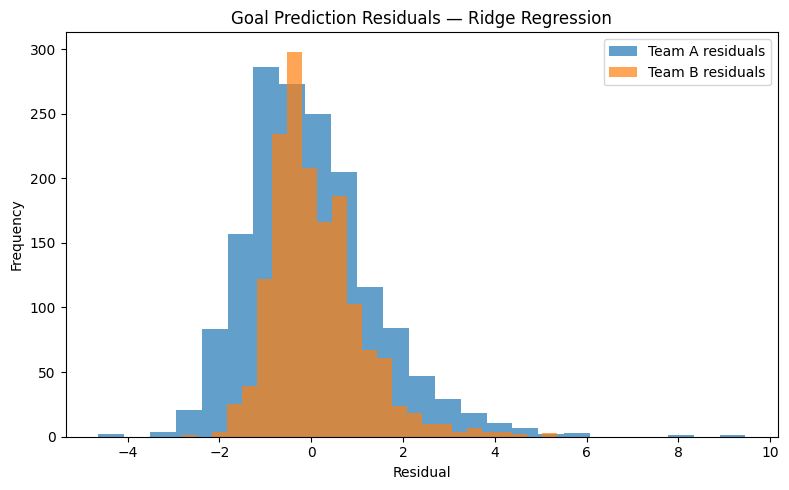

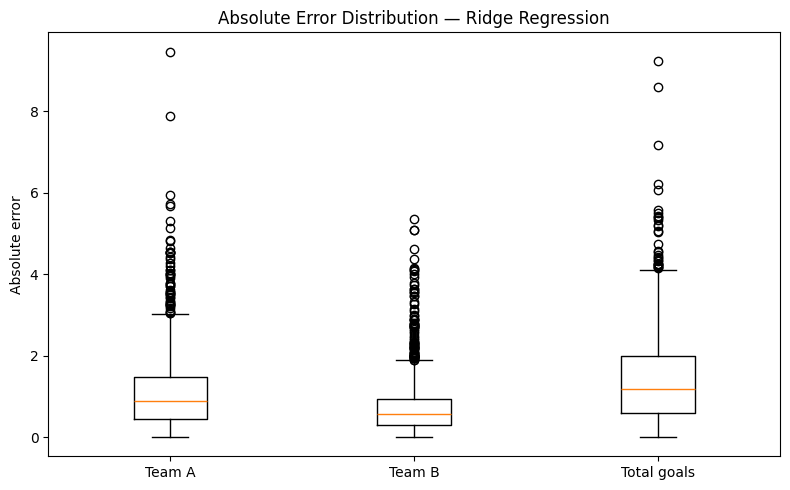

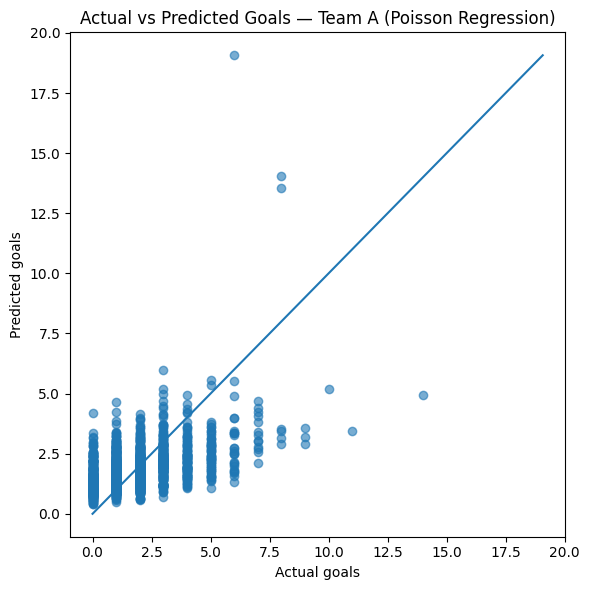

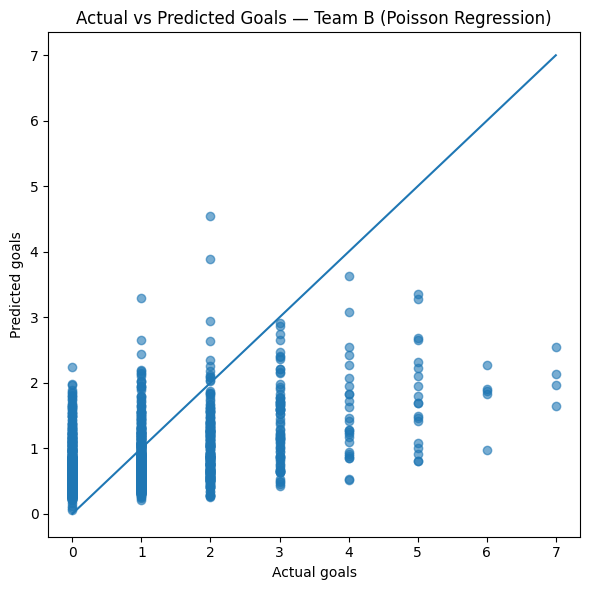

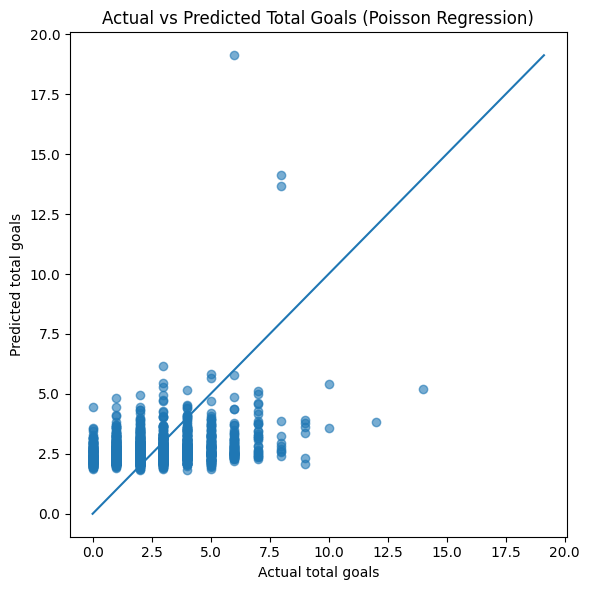

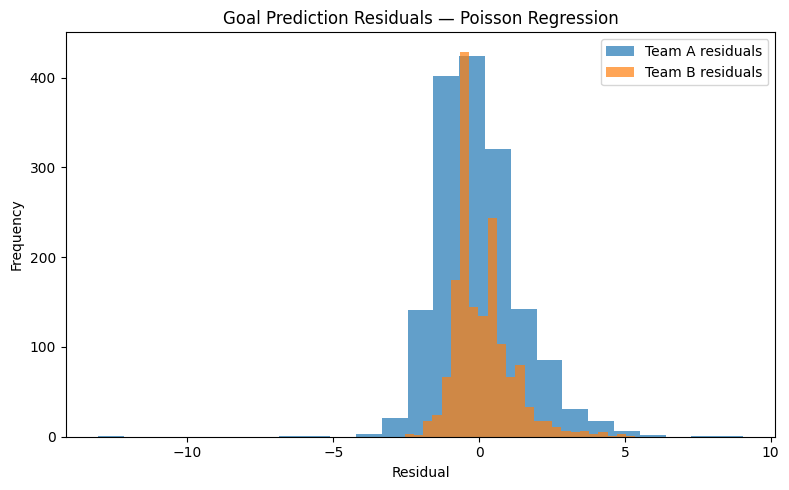

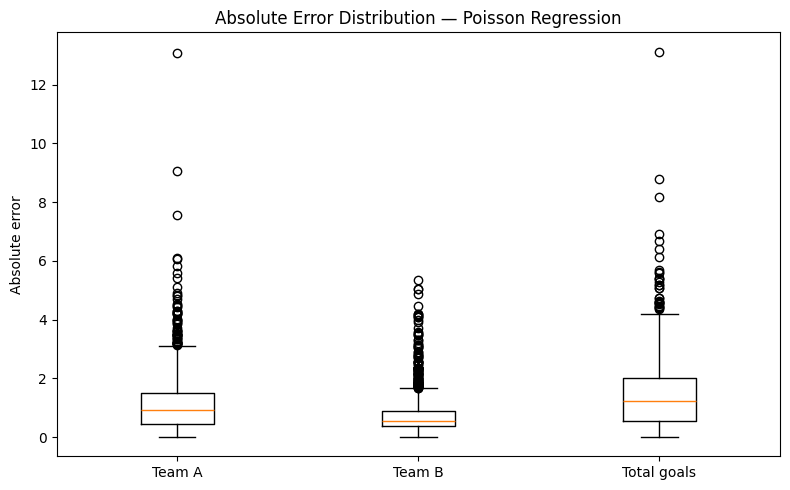

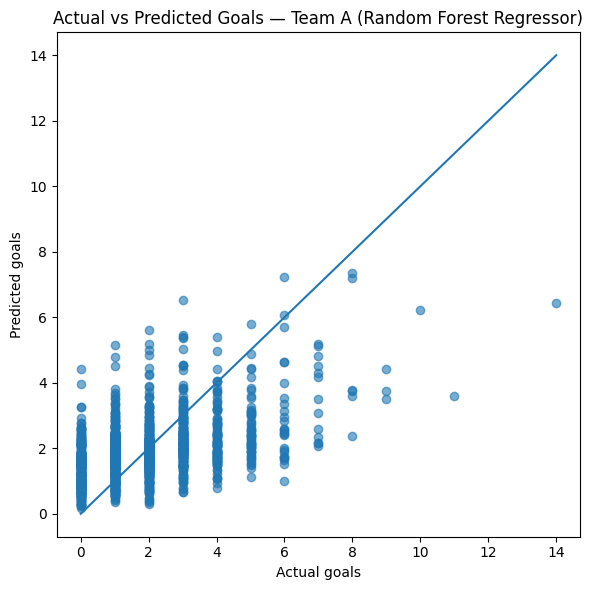

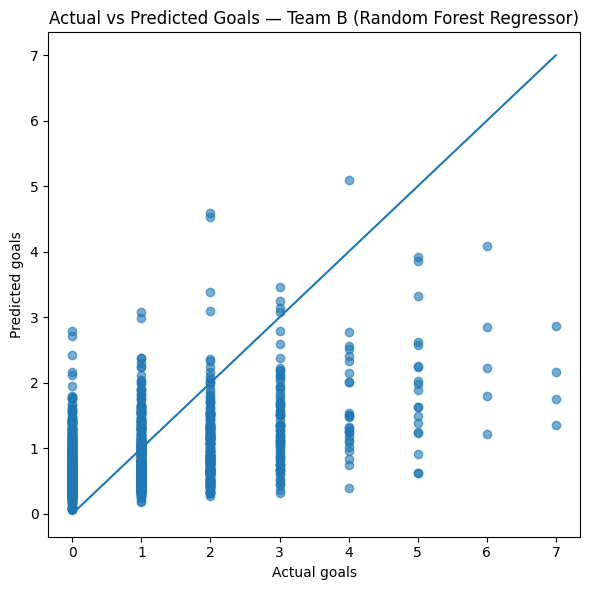

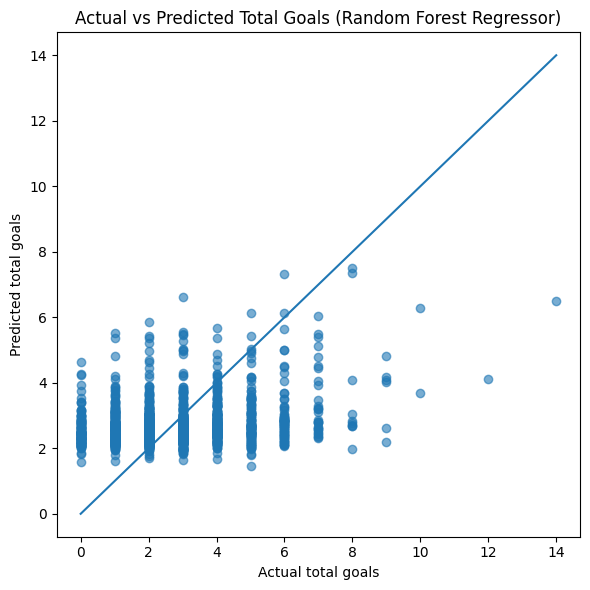

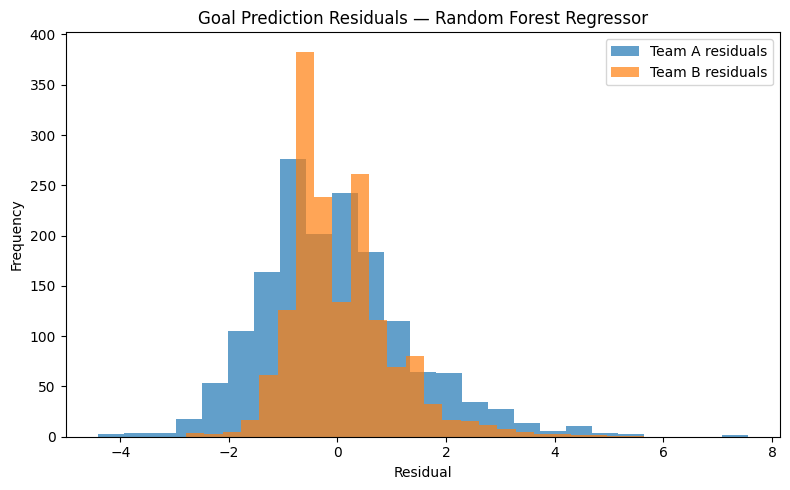

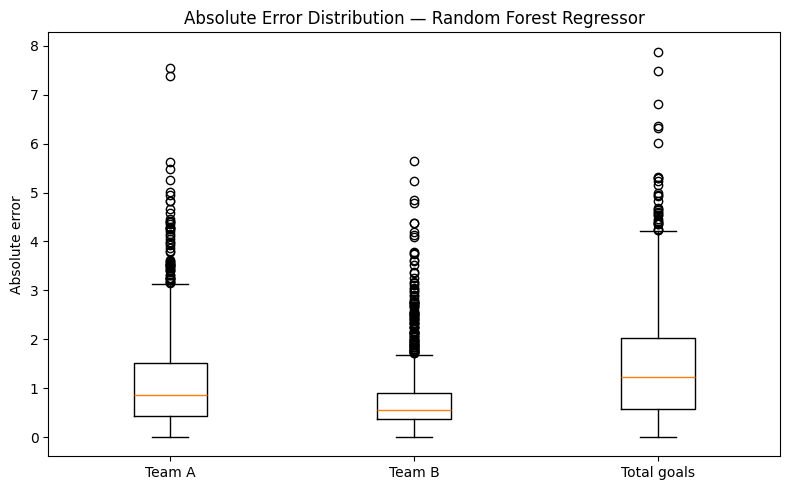

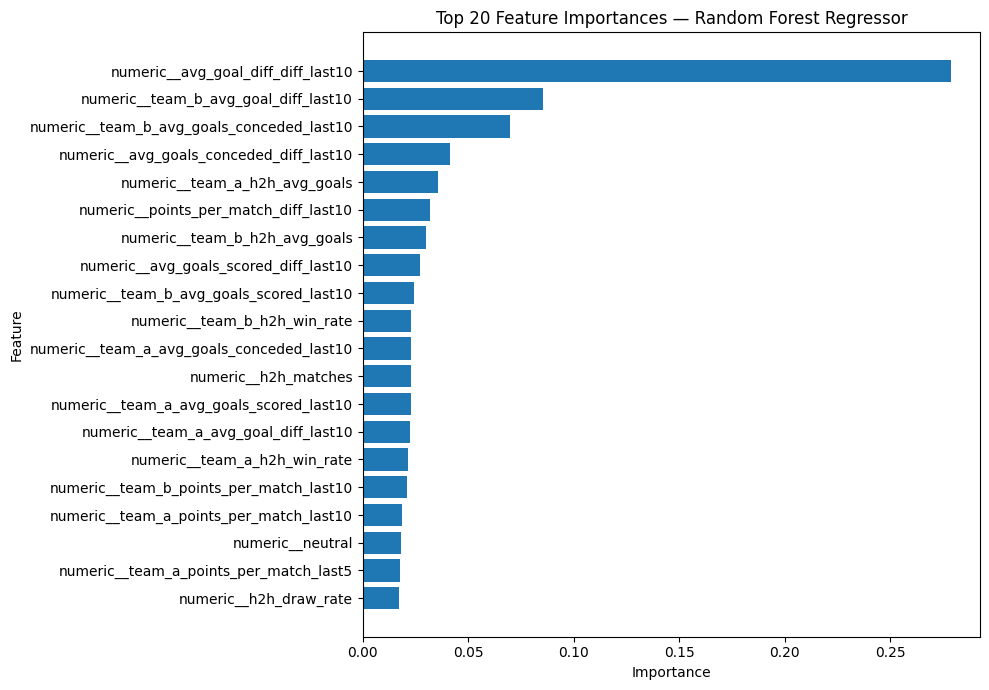

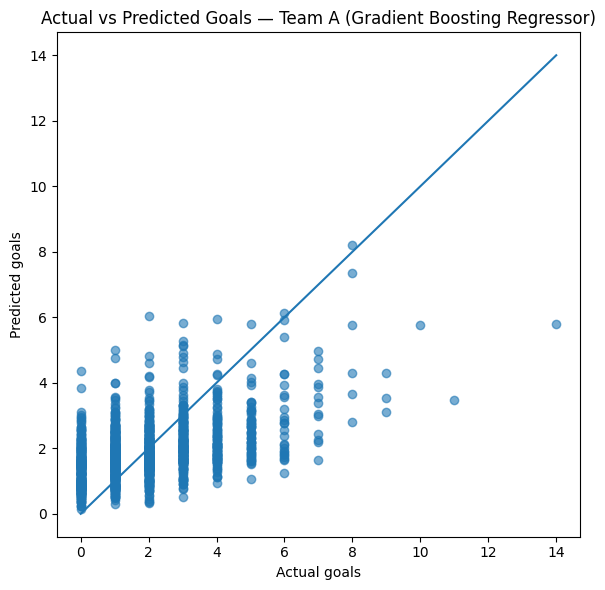

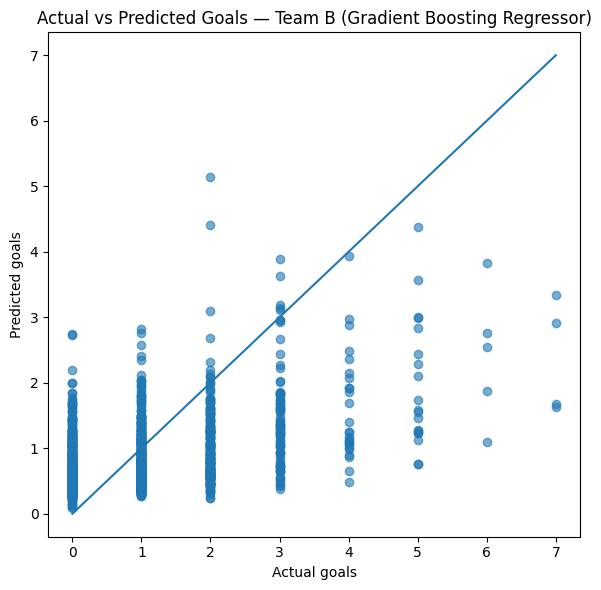

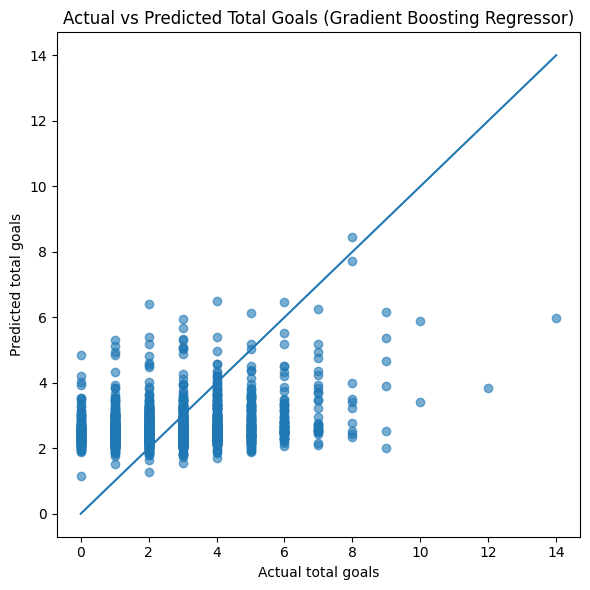

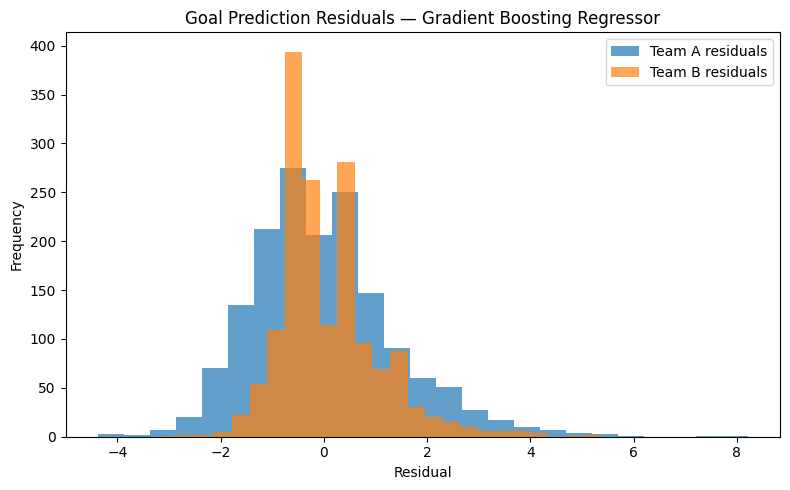

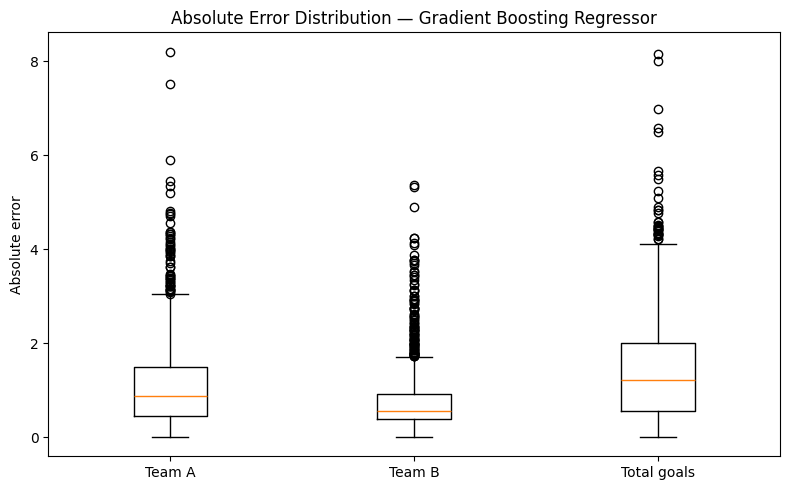

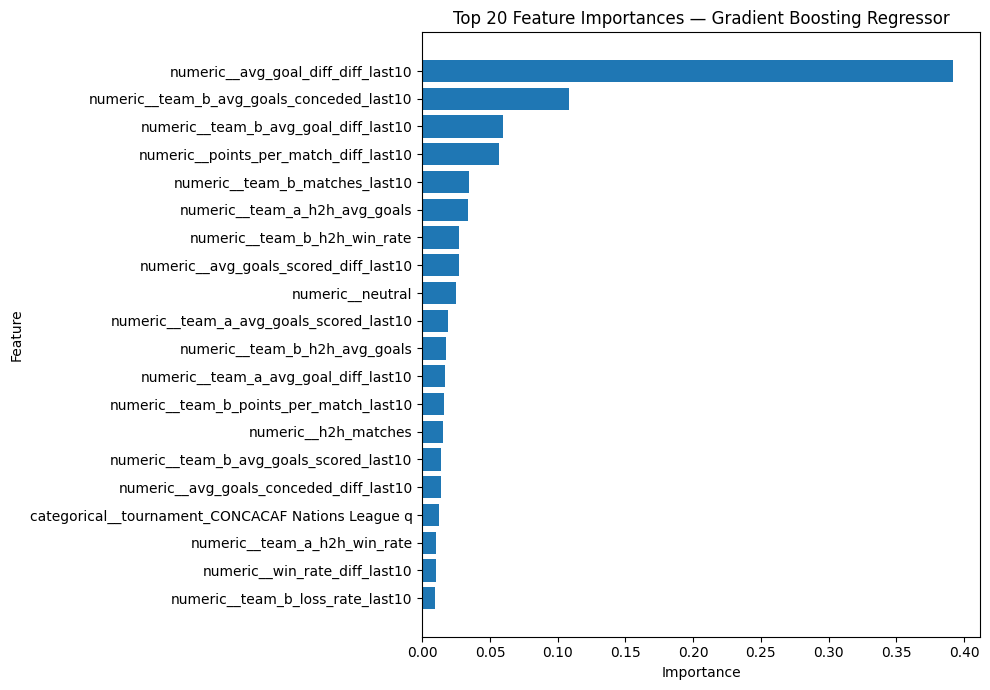

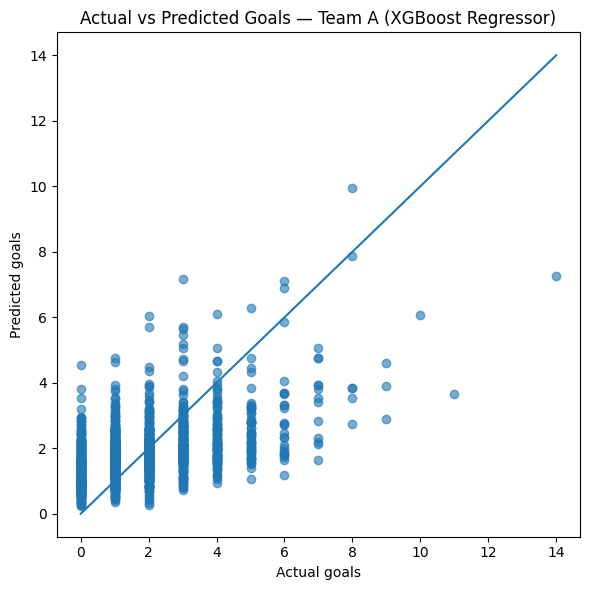

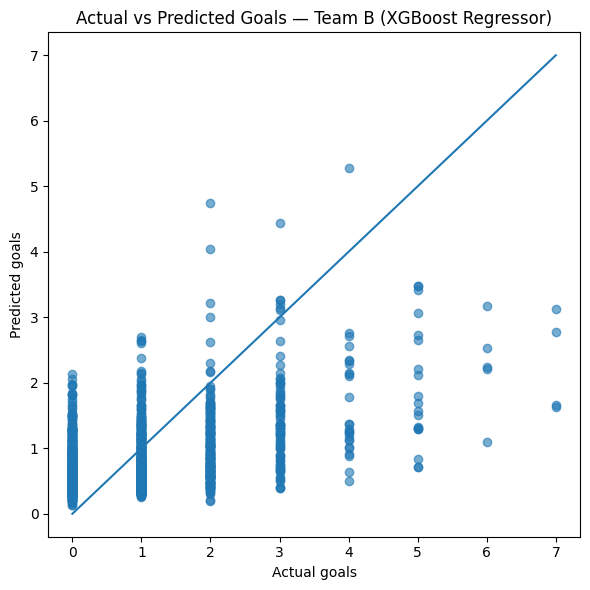

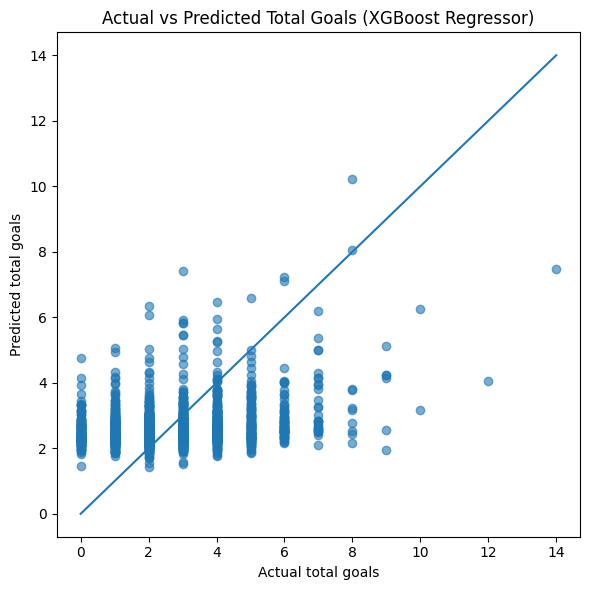

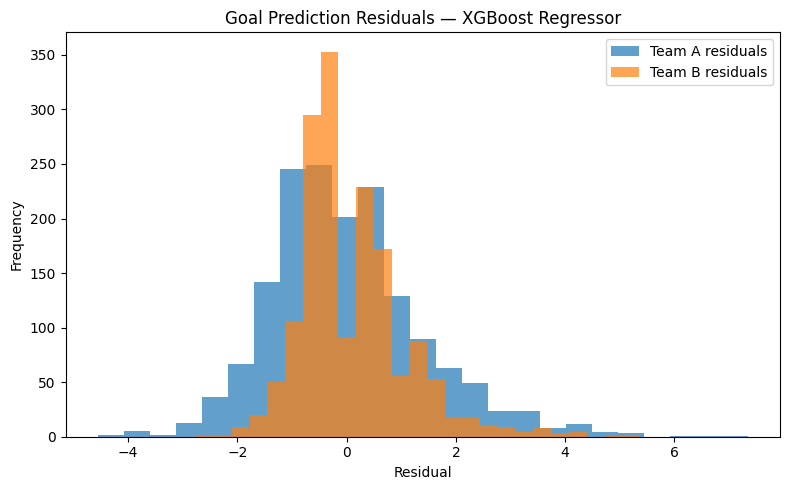

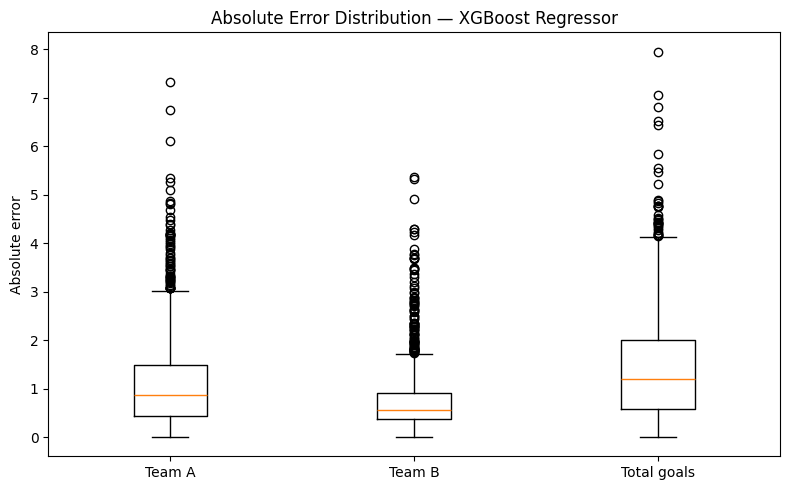

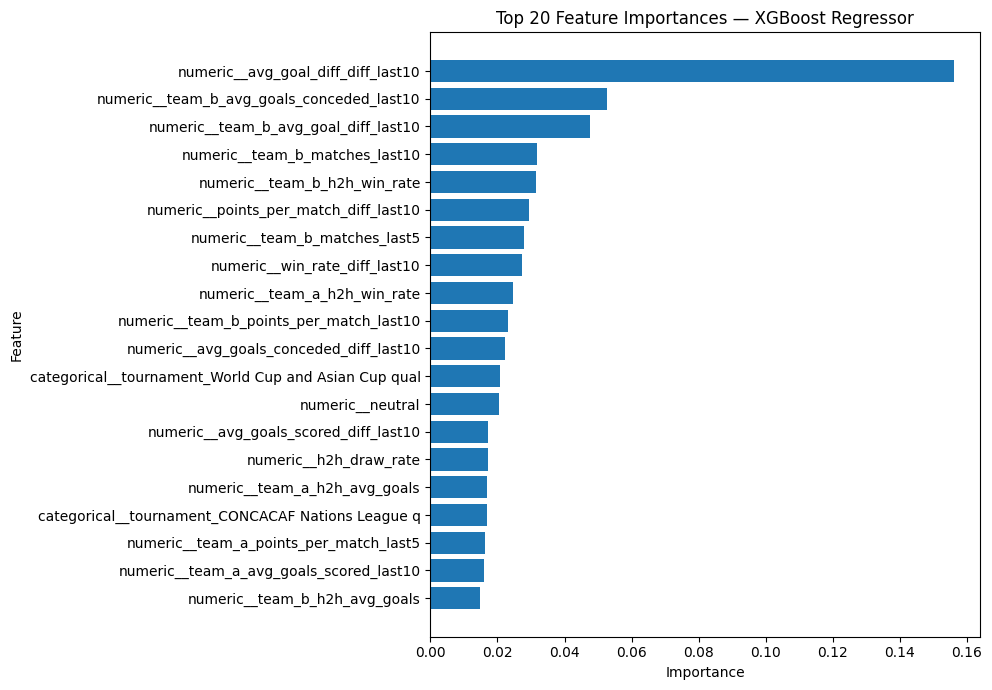

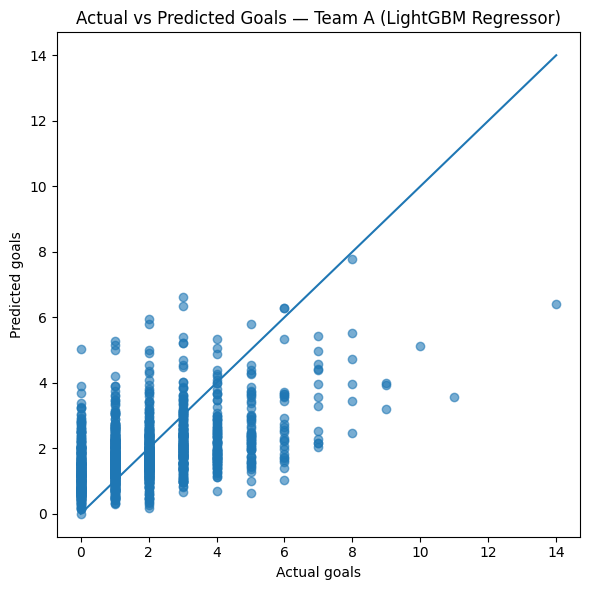

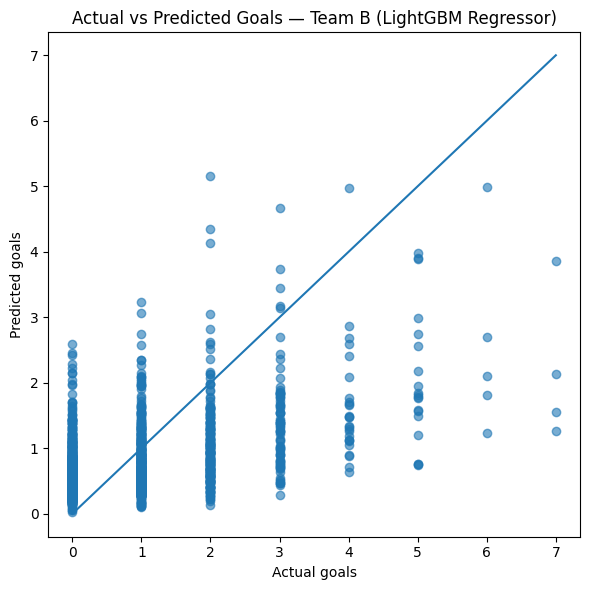

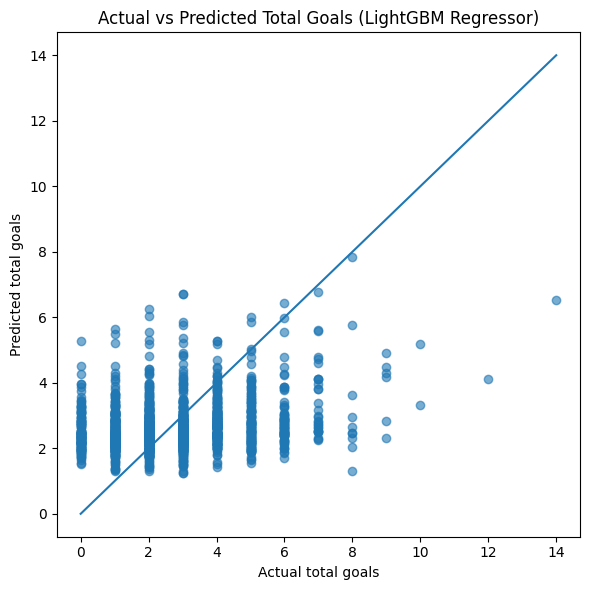

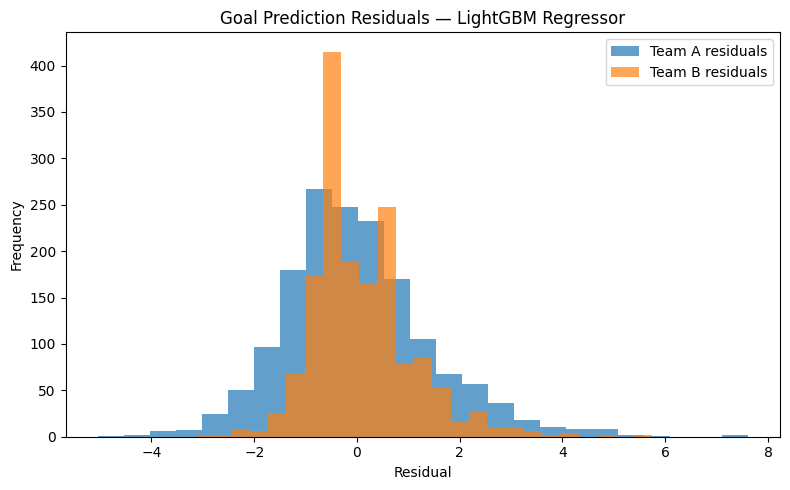

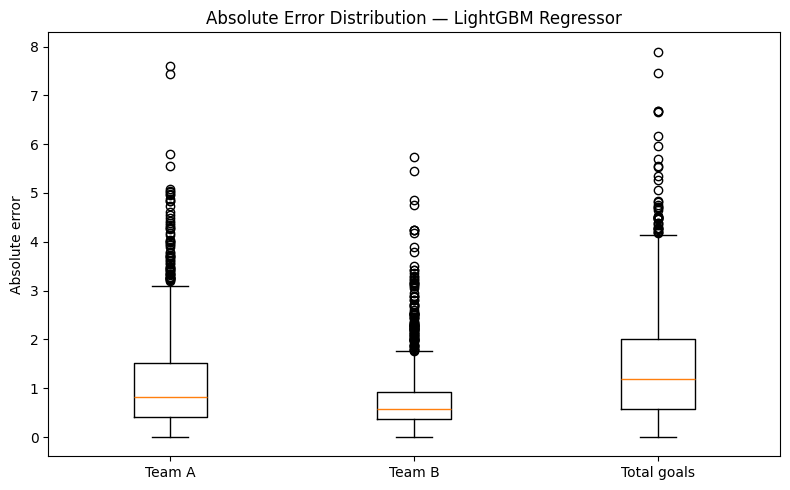

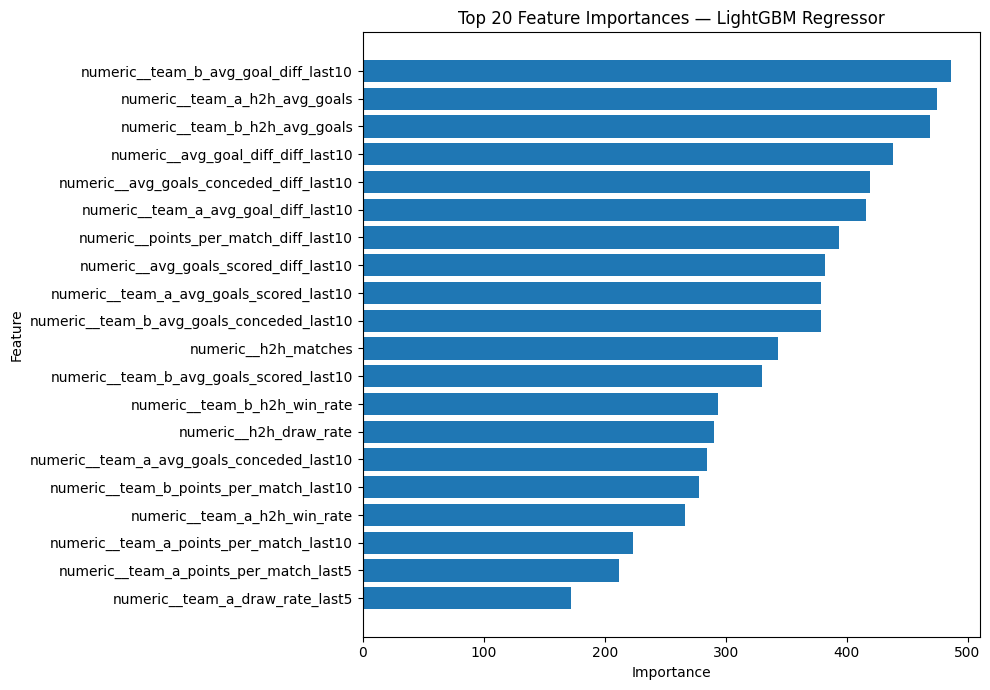

,model,outcome_accuracy,exact_score_accuracy,mean_absolute_goal_error_per_match,figure_folder,feature_importance_saved
0,Dummy Mean Baseline,0.581875,0.090625,2.071218,C:\Users\esmae\Documents\Educx Kurs machine le...,False
1,Ridge Regression,0.612500,0.116250,1.826026,C:\Users\esmae\Documents\Educx Kurs machine le...,False
2,Poisson Regression,0.623750,0.119375,1.850808,C:\Users\esmae\Documents\Educx Kurs machine le...,False
3,Random Forest Regressor,0.627500,0.117500,1.833894,C:\Users\esmae\Documents\Educx Kurs machine le...,True
4,Gradient Boosting Regressor,0.624375,0.115625,1.825938,C:\Users\esmae\Documents\Educx Kurs machine le...,True
5,XGBoost Regressor,0.618125,0.116250,1.828444,C:\Users\esmae\Documents\Educx Kurs machine le...,True
6,LightGBM Regressor,0.628750,0.125625,1.845563,C:\Users\esmae\Documents\Educx Kurs machine le...,True


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\tables\per_model_plot_summary.csv


In [25]:
per_model_summary = []

actual_total_goals = y_test_a + y_test_b

for model_name, (pred_a, pred_b) in predictions_by_model.items():
    model_slug = slugify_model_name(model_name)
    model_dir = PER_MODEL_FIGURES_DIR / model_slug
    model_dir.mkdir(parents=True, exist_ok=True)

    pred_total = pred_a + pred_b
    rounded_a = np.round(pred_a).astype(int)
    rounded_b = np.round(pred_b).astype(int)

    residuals_a = y_test_a - pred_a
    residuals_b = y_test_b - pred_b
    total_residuals = actual_total_goals - pred_total

    # outcome accuracy from rounded predicted scores
    predicted_outcome = np.where(
        rounded_a > rounded_b, "team_a_win",
        np.where(rounded_a < rounded_b, "team_b_win", "draw")
    )
    outcome_accuracy = np.mean(predicted_outcome == test_data["result"].values)
    exact_score_accuracy = np.mean(
        (rounded_a == y_test_a.astype(int)) &
        (rounded_b == y_test_b.astype(int))
    )
    mean_abs_error = np.mean(np.abs(residuals_a) + np.abs(residuals_b))

    # Plot 1: Team A actual vs predicted
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_test_a, pred_a, alpha=0.6)
    min_val = min(y_test_a.min(), pred_a.min())
    max_val = max(y_test_a.max(), pred_a.max())
    ax.plot([min_val, max_val], [min_val, max_val])
    ax.set_title(f"Actual vs Predicted Goals — Team A ({model_name})")
    ax.set_xlabel("Actual goals")
    ax.set_ylabel("Predicted goals")
    fig.tight_layout()
    fig.savefig(model_dir / f"{model_slug}_team_a_actual_vs_predicted.png", dpi=150)
    plt.show()

    # Plot 2: Team B actual vs predicted
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_test_b, pred_b, alpha=0.6)
    min_val = min(y_test_b.min(), pred_b.min())
    max_val = max(y_test_b.max(), pred_b.max())
    ax.plot([min_val, max_val], [min_val, max_val])
    ax.set_title(f"Actual vs Predicted Goals — Team B ({model_name})")
    ax.set_xlabel("Actual goals")
    ax.set_ylabel("Predicted goals")
    fig.tight_layout()
    fig.savefig(model_dir / f"{model_slug}_team_b_actual_vs_predicted.png", dpi=150)
    plt.show()

    # Plot 3: total goals actual vs predicted
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(actual_total_goals, pred_total, alpha=0.6)
    min_val = min(actual_total_goals.min(), pred_total.min())
    max_val = max(actual_total_goals.max(), pred_total.max())
    ax.plot([min_val, max_val], [min_val, max_val])
    ax.set_title(f"Actual vs Predicted Total Goals ({model_name})")
    ax.set_xlabel("Actual total goals")
    ax.set_ylabel("Predicted total goals")
    fig.tight_layout()
    fig.savefig(model_dir / f"{model_slug}_total_goals_actual_vs_predicted.png", dpi=150)
    plt.show()

    # Plot 4: residual distribution
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(residuals_a, bins=25, alpha=0.7, label="Team A residuals")
    ax.hist(residuals_b, bins=25, alpha=0.7, label="Team B residuals")
    ax.set_title(f"Goal Prediction Residuals — {model_name}")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Frequency")
    ax.legend()
    fig.tight_layout()
    fig.savefig(model_dir / f"{model_slug}_residual_distribution.png", dpi=150)
    plt.show()

    # Plot 5: absolute error by target side
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.boxplot([
        np.abs(residuals_a),
        np.abs(residuals_b),
        np.abs(total_residuals),
    ], labels=["Team A", "Team B", "Total goals"])
    ax.set_title(f"Absolute Error Distribution — {model_name}")
    ax.set_ylabel("Absolute error")
    fig.tight_layout()
    fig.savefig(model_dir / f"{model_slug}_absolute_error_boxplot.png", dpi=150)
    plt.show()

    # Plot 6: feature importance when available
    model_a, _ = trained_models[model_name]
    estimator = model_a.named_steps["model"]
    transformer = model_a.named_steps["preprocessor"]
    feature_importance_saved = False

    if hasattr(estimator, "feature_importances_"):
        feature_names = transformer.get_feature_names_out()
        importance_df = pd.DataFrame({
            "feature": feature_names,
            "importance": estimator.feature_importances_,
        }).sort_values("importance", ascending=False)

        top_importance = importance_df.head(20).sort_values("importance", ascending=True)

        fig, ax = plt.subplots(figsize=(10, 7))
        ax.barh(top_importance["feature"], top_importance["importance"])
        ax.set_title(f"Top 20 Feature Importances — {model_name}")
        ax.set_xlabel("Importance")
        ax.set_ylabel("Feature")
        fig.tight_layout()
        fig.savefig(model_dir / f"{model_slug}_feature_importance.png", dpi=150)
        plt.show()

        importance_df.to_csv(model_dir / f"{model_slug}_feature_importance.csv", index=False)
        feature_importance_saved = True

    per_model_summary.append({
        "model": model_name,
        "outcome_accuracy": outcome_accuracy,
        "exact_score_accuracy": exact_score_accuracy,
        "mean_absolute_goal_error_per_match": mean_abs_error,
        "figure_folder": str(model_dir),
        "feature_importance_saved": feature_importance_saved,
    })

per_model_summary_df = pd.DataFrame(per_model_summary)
display(per_model_summary_df)
per_model_summary_df.to_csv(TABLES_DIR / "per_model_plot_summary.csv", index=False)
print("Saved:", TABLES_DIR / "per_model_plot_summary.csv")


## Separate Per-Model Output Structure

Each model now has its own subfolder inside `output/regression_model_comparison_presentation/figures_per_model/`.

Inside each model folder, the notebook saves: 
- Team A actual vs predicted
- Team B actual vs predicted
- Total goals actual vs predicted
- Residual distribution
- Absolute error boxplot
- Feature importance (only for tree-based models that support it)


In [26]:
print("Per-model figure folders:")
for _, row in per_model_summary_df.iterrows():
    print(f" - {row['model']}: {row['figure_folder']}")


Per-model figure folders:
 - Dummy Mean Baseline: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\figures_per_model\dummy_mean_baseline
 - Ridge Regression: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\figures_per_model\ridge_regression
 - Poisson Regression: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\figures_per_model\poisson_regression
 - Random Forest Regressor: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\figures_per_model\random_forest_regressor
 - Gradient Boosting Regressor: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_pr

## Extra Presentation Section 1 — Team Profile Construction

This section creates team-level historical profiles from the match dataset. These profiles are used for PCA, clustering, and group-strength visualization.


In [27]:
team_rows = []

for _, row in model_dataset.iterrows():
    team_rows.append({
        "team": row["team_a"],
        "goals_for": row["team_a_goals"],
        "goals_against": row["team_b_goals"],
        "goal_diff": row["team_a_goals"] - row["team_b_goals"],
        "points": 3 if row["team_a_goals"] > row["team_b_goals"] else (1 if row["team_a_goals"] == row["team_b_goals"] else 0),
        "result_win": 1 if row["team_a_goals"] > row["team_b_goals"] else 0,
        "result_draw": 1 if row["team_a_goals"] == row["team_b_goals"] else 0,
        "result_loss": 1 if row["team_a_goals"] < row["team_b_goals"] else 0,
    })
    team_rows.append({
        "team": row["team_b"],
        "goals_for": row["team_b_goals"],
        "goals_against": row["team_a_goals"],
        "goal_diff": row["team_b_goals"] - row["team_a_goals"],
        "points": 3 if row["team_b_goals"] > row["team_a_goals"] else (1 if row["team_a_goals"] == row["team_b_goals"] else 0),
        "result_win": 1 if row["team_b_goals"] > row["team_a_goals"] else 0,
        "result_draw": 1 if row["team_a_goals"] == row["team_b_goals"] else 0,
        "result_loss": 1 if row["team_b_goals"] < row["team_a_goals"] else 0,
    })

team_profile_raw = pd.DataFrame(team_rows)

team_profile = (
    team_profile_raw
    .groupby("team")
    .agg(
        matches=("team", "size"),
        avg_goals_for=("goals_for", "mean"),
        avg_goals_against=("goals_against", "mean"),
        avg_goal_diff=("goal_diff", "mean"),
        avg_points=("points", "mean"),
        win_rate=("result_win", "mean"),
        draw_rate=("result_draw", "mean"),
        loss_rate=("result_loss", "mean"),
    )
    .reset_index()
    .sort_values("avg_points", ascending=False)
    .reset_index(drop=True)
)

display(team_profile.head(20))
team_profile.to_csv(TABLES_DIR / "team_profile_summary.csv", index=False)
print("Saved:", TABLES_DIR / "team_profile_summary.csv")



,team,matches,avg_goals_for,avg_goals_against,avg_goal_diff,avg_points,win_rate,draw_rate,loss_rate
0,Spain,255,2.317647,0.713725,1.603922,2.325490,0.713725,0.184314,0.101961
1,Brazil,258,2.077519,0.686047,1.391473,2.193798,0.662791,0.205426,0.131783
2,Argentina,255,1.941176,0.764706,1.176471,2.133333,0.639216,0.215686,0.145098
3,England,233,2.068670,0.729614,1.339056,2.081545,0.622318,0.214592,0.163090
4,IR Iran,250,1.876000,0.684000,1.192000,2.072000,0.612000,0.236000,0.152000
5,France,249,1.851406,0.835341,1.016064,2.036145,0.606426,0.216867,0.176707
6,Germany,250,2.312000,1.048000,1.264000,2.032000,0.608000,0.208000,0.184000
7,Portugal,242,2.057851,0.826446,1.231405,2.020661,0.595041,0.235537,0.169421
8,Netherlands,235,2.140426,0.931915,1.208511,2.008511,0.600000,0.208511,0.191489
9,Japan,280,2.075000,0.867857,1.207143,1.992857,0.596429,0.203571,0.200000


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\tables\team_profile_summary.csv


## Extra Presentation Section 2 — PCA Team Map

Teams are projected into a 2D space using PCA. Teams with similar historical performance should appear closer together.


## Interactive Team Maps Helper

This helper saves both clean static PNG charts and interactive Plotly HTML charts where team names appear only on hover.


In [28]:
# fallback setup for interactive figures
if "COMPARISON_DIR" not in globals():
    COMPARISON_DIR = Path("..").resolve() / "output" / "regression_model_comparison_presentation"

if "EXTRA_FIGURES_DIR" not in globals():
    EXTRA_FIGURES_DIR = COMPARISON_DIR / "figures_extra"

if "INTERACTIVE_FIGURES_DIR" not in globals():
    INTERACTIVE_FIGURES_DIR = COMPARISON_DIR / "figures_interactive"

EXTRA_FIGURES_DIR.mkdir(parents=True, exist_ok=True)
INTERACTIVE_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_clean_static_scatter(dataframe, x_col, y_col, title, x_label, y_label, png_path, color_col=None):
    fig, ax = plt.subplots(figsize=(10, 7))
    if color_col is None:
        ax.scatter(dataframe[x_col], dataframe[y_col], alpha=0.75, s=45)
    else:
        ax.scatter(dataframe[x_col], dataframe[y_col], c=dataframe[color_col], alpha=0.8, s=50)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    fig.tight_layout()
    fig.savefig(png_path, dpi=150)
    plt.show()
    print("Saved:", png_path)


def save_interactive_team_scatter(
    dataframe,
    x_col,
    y_col,
    title,
    x_label,
    y_label,
    html_path,
    color_col=None,
    extra_hover_cols=None,
):
    if not PLOTLY_AVAILABLE:
        print("Plotly is not available. Interactive HTML was not created:", html_path)
        return

    hover_columns = []
    if extra_hover_cols is not None:
        hover_columns = [col for col in extra_hover_cols if col in dataframe.columns]

    fig = px.scatter(
        dataframe,
        x=x_col,
        y=y_col,
        color=color_col if color_col is not None else None,
        hover_name="team",
        hover_data=hover_columns,
        title=title,
        width=1100,
        height=800,
    )
    fig.update_traces(marker=dict(size=9, opacity=0.82))
    fig.update_layout(template="plotly_white", xaxis_title=x_label, yaxis_title=y_label)
    fig.show()
    fig.write_html(str(html_path))
    print("Saved:", html_path)



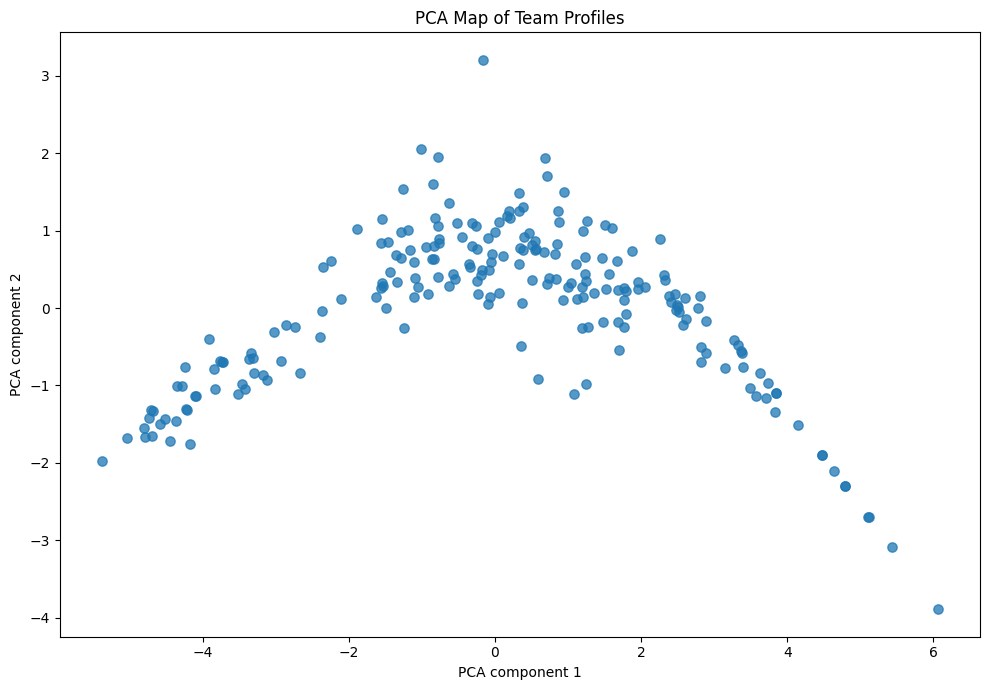

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\extra_presentation_figures\16_team_profile_pca_map_clean.png


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\interactive_figures\16_team_profile_pca_map_interactive.html


,component,explained_variance_ratio
0,PC1,0.784206
1,PC2,0.129768


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\tables\team_profile_pca_summary.csv


In [29]:
profile_features = [
    "matches",
    "avg_goals_for",
    "avg_goals_against",
    "avg_goal_diff",
    "avg_points",
    "win_rate",
    "draw_rate",
    "loss_rate",
]

profile_matrix = team_profile[profile_features].copy()

profile_scaler = StandardScaler()
profile_scaled = profile_scaler.fit_transform(profile_matrix)

pca = PCA(n_components=2, random_state=42)
team_profile_pca = pca.fit_transform(profile_scaled)

team_profile["pca_1"] = team_profile_pca[:, 0]
team_profile["pca_2"] = team_profile_pca[:, 1]

save_clean_static_scatter(
    team_profile,
    x_col="pca_1",
    y_col="pca_2",
    title="PCA Map of Team Profiles",
    x_label="PCA component 1",
    y_label="PCA component 2",
    png_path=EXTRA_FIGURES_DIR / "16_team_profile_pca_map_clean.png",
)

save_interactive_team_scatter(
    team_profile,
    x_col="pca_1",
    y_col="pca_2",
    title="PCA Map of Team Profiles (Hover to See Team Names)",
    x_label="PCA component 1",
    y_label="PCA component 2",
    html_path=INTERACTIVE_FIGURES_DIR / "16_team_profile_pca_map_interactive.html",
    extra_hover_cols=profile_features,
)

pca_summary = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca.explained_variance_ratio_,
})

display(pca_summary)
pca_summary.to_csv(TABLES_DIR / "team_profile_pca_summary.csv", index=False)
print("Saved:", TABLES_DIR / "team_profile_pca_summary.csv")


## Extra Presentation Section 3 — t-SNE Team Map

This nonlinear projection is useful for a more presentation-friendly visual separation of teams.


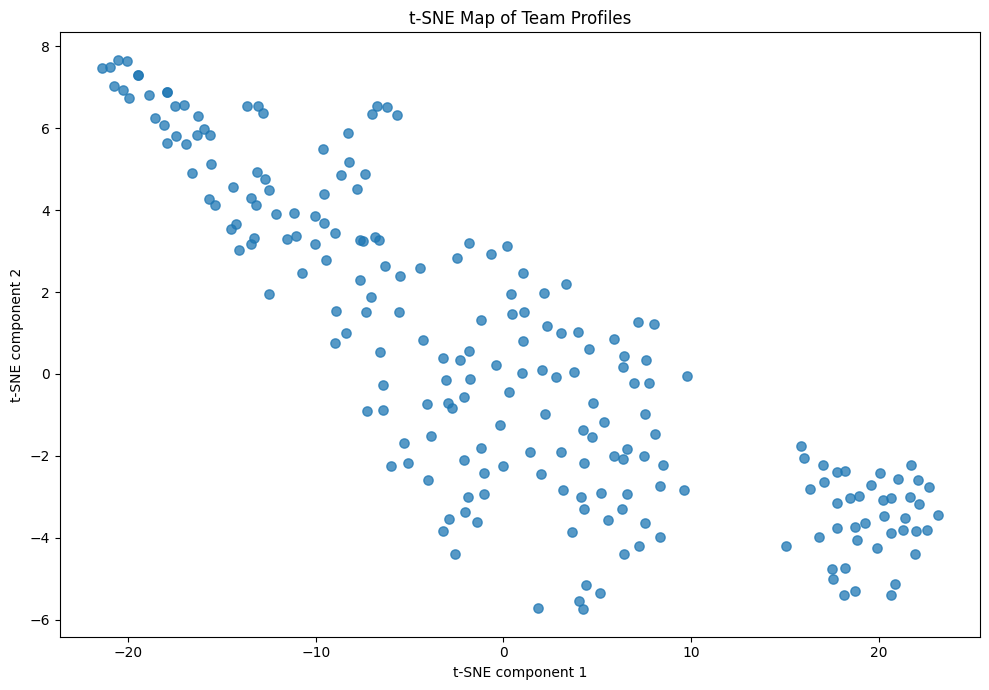

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\extra_presentation_figures\17_team_profile_tsne_map_clean.png


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\interactive_figures\17_team_profile_tsne_map_interactive.html


In [30]:
if len(team_profile) >= 5:
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max(5, len(team_profile) // 4)))
    team_profile_tsne = tsne.fit_transform(profile_scaled)

    team_profile["tsne_1"] = team_profile_tsne[:, 0]
    team_profile["tsne_2"] = team_profile_tsne[:, 1]

    save_clean_static_scatter(
        team_profile,
        x_col="tsne_1",
        y_col="tsne_2",
        title="t-SNE Map of Team Profiles",
        x_label="t-SNE component 1",
        y_label="t-SNE component 2",
        png_path=EXTRA_FIGURES_DIR / "17_team_profile_tsne_map_clean.png",
    )

    save_interactive_team_scatter(
        team_profile,
        x_col="tsne_1",
        y_col="tsne_2",
        title="t-SNE Map of Team Profiles (Hover to See Team Names)",
        x_label="t-SNE component 1",
        y_label="t-SNE component 2",
        html_path=INTERACTIVE_FIGURES_DIR / "17_team_profile_tsne_map_interactive.html",
        extra_hover_cols=profile_features,
    )
else:
    print("Not enough teams available for t-SNE.")


## Extra Presentation Section 4 — UMAP Team Map

UMAP is optional. If the package is installed, a third 2D team map is generated.


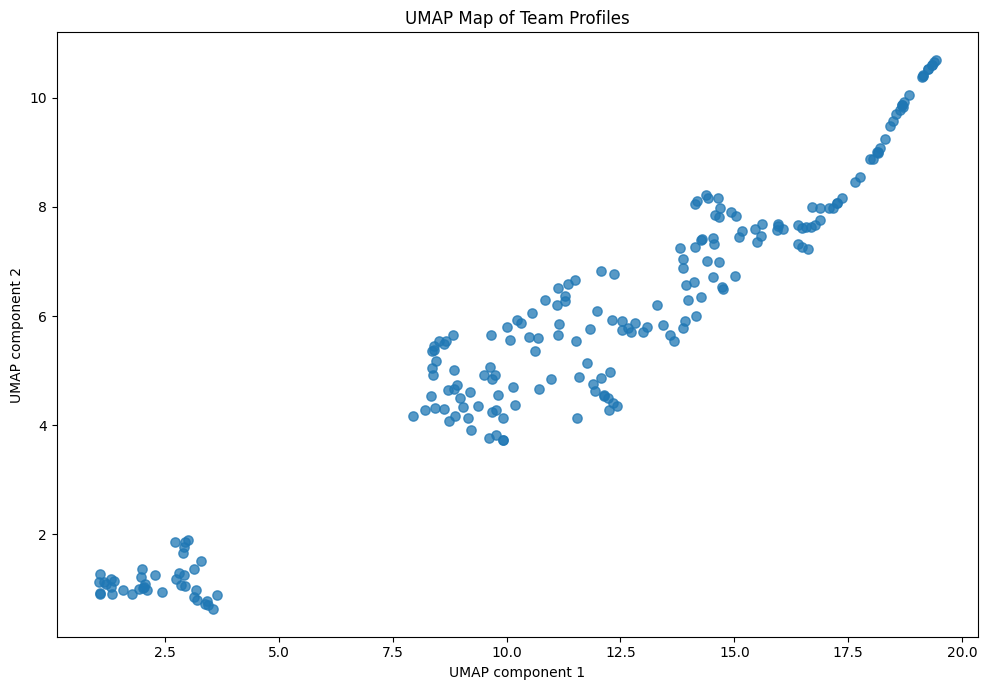

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\extra_presentation_figures\18_team_profile_umap_map_clean.png


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\interactive_figures\18_team_profile_umap_map_interactive.html


In [31]:
if UMAP_AVAILABLE and len(team_profile) >= 5:
    reducer = umap.UMAP(n_components=2, random_state=42)
    team_profile_umap = reducer.fit_transform(profile_scaled)

    team_profile["umap_1"] = team_profile_umap[:, 0]
    team_profile["umap_2"] = team_profile_umap[:, 1]

    save_clean_static_scatter(
        team_profile,
        x_col="umap_1",
        y_col="umap_2",
        title="UMAP Map of Team Profiles",
        x_label="UMAP component 1",
        y_label="UMAP component 2",
        png_path=EXTRA_FIGURES_DIR / "18_team_profile_umap_map_clean.png",
    )

    save_interactive_team_scatter(
        team_profile,
        x_col="umap_1",
        y_col="umap_2",
        title="UMAP Map of Team Profiles (Hover to See Team Names)",
        x_label="UMAP component 1",
        y_label="UMAP component 2",
        html_path=INTERACTIVE_FIGURES_DIR / "18_team_profile_umap_map_interactive.html",
        extra_hover_cols=profile_features,
    )
else:
    print("UMAP is not available or there are not enough teams.")


## Extra Presentation Section 5 — Team Clustering

K-means clustering groups similar teams into performance clusters.


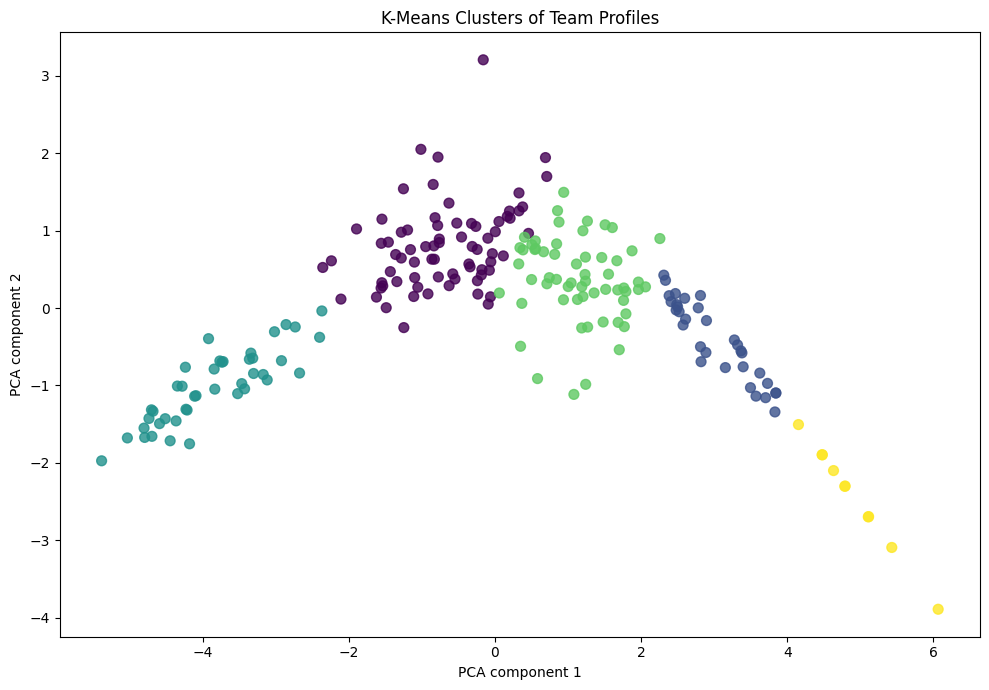

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\extra_presentation_figures\19_team_clustering_kmeans_clean.png


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\interactive_figures\19_team_clustering_kmeans_interactive.html


,cluster,matches,avg_goals_for,avg_goals_against,avg_goal_diff,avg_points,win_rate,draw_rate,loss_rate
2,2,235.547619,1.684227,0.970448,0.713779,1.771143,0.511345,0.237110,0.251546
0,0,58.945205,0.838591,1.649378,-0.810788,0.836012,0.186633,0.276114,0.537253
3,3,24.372881,0.585689,2.518755,-1.933066,0.372656,0.080384,0.131503,0.788112
1,1,10.906250,0.177399,4.292675,-4.115276,0.026698,0.001157,0.023226,0.975617
4,4,1.700000,0.000000,9.350000,-9.350000,0.000000,0.000000,0.000000,1.000000


Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\tables\team_cluster_summary.csv


In [32]:
n_clusters = min(5, max(3, len(team_profile) // 10))
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
team_profile["cluster"] = kmeans.fit_predict(profile_scaled)

save_clean_static_scatter(
    team_profile,
    x_col="pca_1",
    y_col="pca_2",
    title="K-Means Clusters of Team Profiles",
    x_label="PCA component 1",
    y_label="PCA component 2",
    png_path=EXTRA_FIGURES_DIR / "19_team_clustering_kmeans_clean.png",
    color_col="cluster",
)

save_interactive_team_scatter(
    team_profile,
    x_col="pca_1",
    y_col="pca_2",
    title="K-Means Clusters of Team Profiles (Hover to See Team Names)",
    x_label="PCA component 1",
    y_label="PCA component 2",
    html_path=INTERACTIVE_FIGURES_DIR / "19_team_clustering_kmeans_interactive.html",
    color_col="cluster",
    extra_hover_cols=profile_features,
)

cluster_summary = (
    team_profile.groupby("cluster")[profile_features]
    .mean()
    .reset_index()
    .sort_values("avg_points", ascending=False)
)

display(cluster_summary)
cluster_summary.to_csv(TABLES_DIR / "team_cluster_summary.csv", index=False)
print("Saved:", TABLES_DIR / "team_cluster_summary.csv")


## Extra Presentation Section 6 — Correlation Heatmap

A feature correlation heatmap helps explain which performance indicators move together.


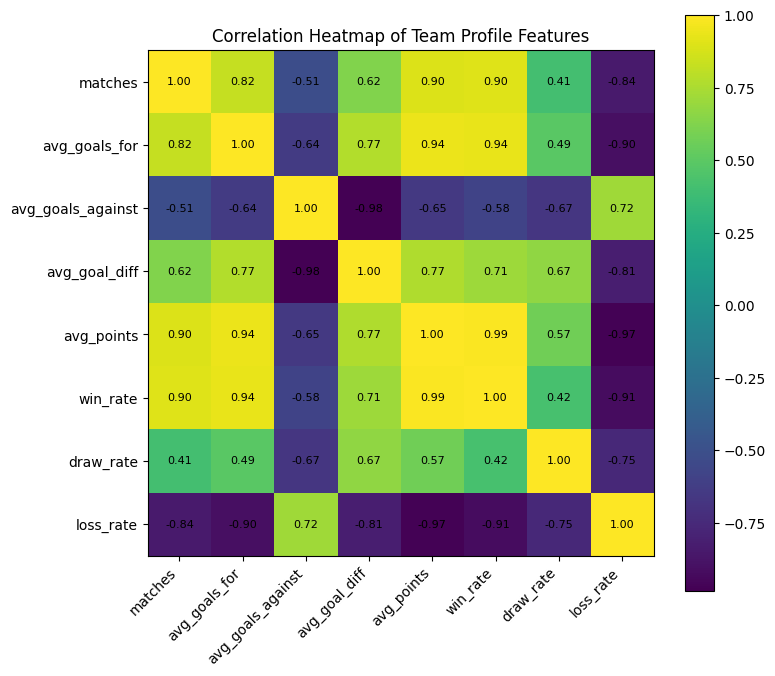

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\extra_presentation_figures\20_team_profile_correlation_heatmap.png
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\tables\team_profile_correlation_matrix.csv


In [33]:
corr_matrix = team_profile[profile_features].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix.values)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.index)

for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Correlation Heatmap of Team Profile Features")
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(EXTRA_FIGURES_DIR / "20_team_profile_correlation_heatmap.png", dpi=150)
plt.show()

corr_matrix.to_csv(TABLES_DIR / "team_profile_correlation_matrix.csv")
print("Saved:", EXTRA_FIGURES_DIR / "20_team_profile_correlation_heatmap.png")
print("Saved:", TABLES_DIR / "team_profile_correlation_matrix.csv")



## Extra Presentation Section 7 — Group Strength Ranking

If World Cup 2026 fixture features are available, the notebook estimates average group strength using historical team-form information.


,group,mean_strength,mean_goal_diff,team_count
9,Group J,2.150,1.475,4
4,Group E,2.050,1.075,4
2,Group C,1.850,1.125,4
11,Group L,1.850,0.750,4
7,Group H,1.750,0.825,4
8,Group I,1.725,1.250,4
6,Group G,1.575,1.000,4
10,Group K,1.500,0.875,4
5,Group F,1.475,0.550,4
0,Group A,1.375,0.425,4


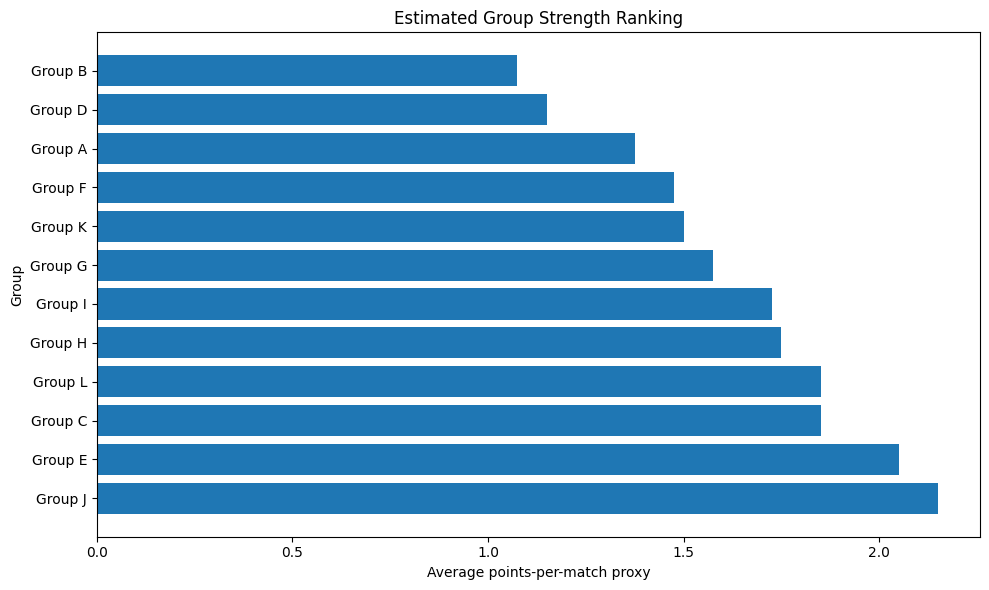

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\extra_presentation_figures\21_group_strength_ranking.png
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\tables\group_strength_ranking.csv


In [34]:
fixture_feature_path = PROCESSED_DIR / "wc2026_fixture_features.csv"

if fixture_feature_path.exists():
    fixture_features_wc = pd.read_csv(fixture_feature_path)
    fixture_features_wc["date"] = pd.to_datetime(fixture_features_wc["date"], errors="coerce")

    fixture_features_wc = fixture_features_wc[
        fixture_features_wc["group"].notna()
        & fixture_features_wc["group"].astype(str).str.startswith("Group ")
    ].copy()

    team_group_rows = []
    for _, row in fixture_features_wc.iterrows():
        team_group_rows.append({
            "group": row["group"],
            "team": row["team_a"],
            "strength_proxy": row.get("team_a_points_per_match_last10", np.nan),
            "goal_diff_proxy": row.get("team_a_avg_goal_diff_last10", np.nan),
        })
        team_group_rows.append({
            "group": row["group"],
            "team": row["team_b"],
            "strength_proxy": row.get("team_b_points_per_match_last10", np.nan),
            "goal_diff_proxy": row.get("team_b_avg_goal_diff_last10", np.nan),
        })

    group_team_df = pd.DataFrame(team_group_rows).drop_duplicates(subset=["group", "team"])

    group_strength = (
        group_team_df.groupby("group")
        .agg(
            mean_strength=("strength_proxy", "mean"),
            mean_goal_diff=("goal_diff_proxy", "mean"),
            team_count=("team", "nunique"),
        )
        .reset_index()
        .sort_values("mean_strength", ascending=False)
    )

    display(group_strength)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(group_strength["group"], group_strength["mean_strength"])
    ax.set_title("Estimated Group Strength Ranking")
    ax.set_xlabel("Average points-per-match proxy")
    ax.set_ylabel("Group")
    fig.tight_layout()
    fig.savefig(EXTRA_FIGURES_DIR / "21_group_strength_ranking.png", dpi=150)
    plt.show()

    group_strength.to_csv(TABLES_DIR / "group_strength_ranking.csv", index=False)
    print("Saved:", EXTRA_FIGURES_DIR / "21_group_strength_ranking.png")
    print("Saved:", TABLES_DIR / "group_strength_ranking.csv")
else:
    print("wc2026_fixture_features.csv was not found. Group-strength chart skipped.")



## Extra Presentation Section 8 — Prediction Confidence and Upset Risk

These plots highlight high-confidence fixtures and potential upset candidates using the best regression model.


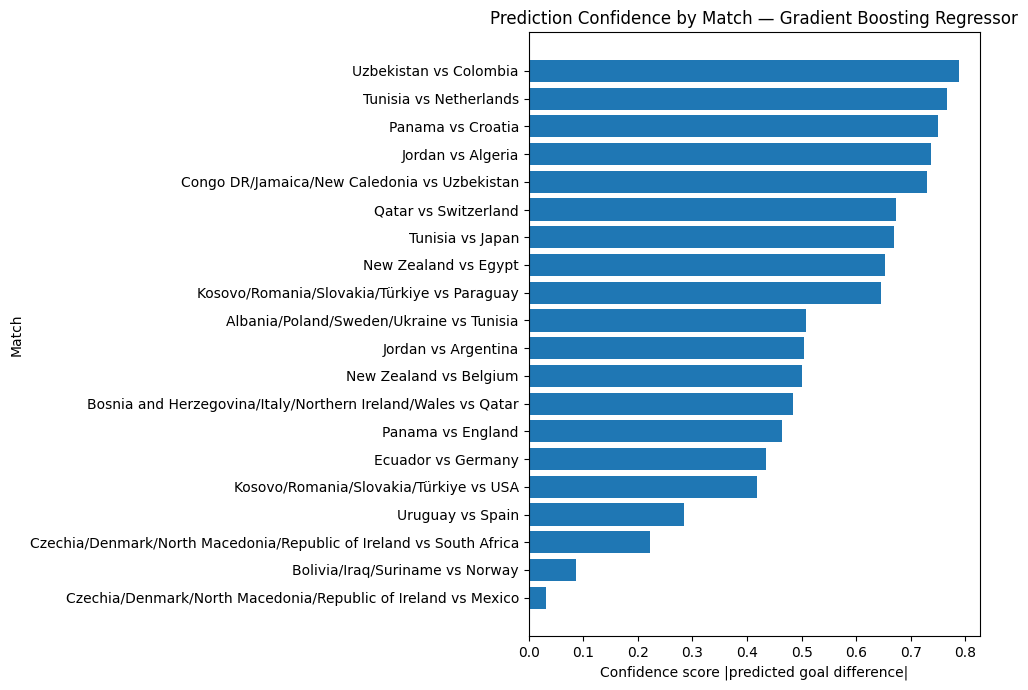

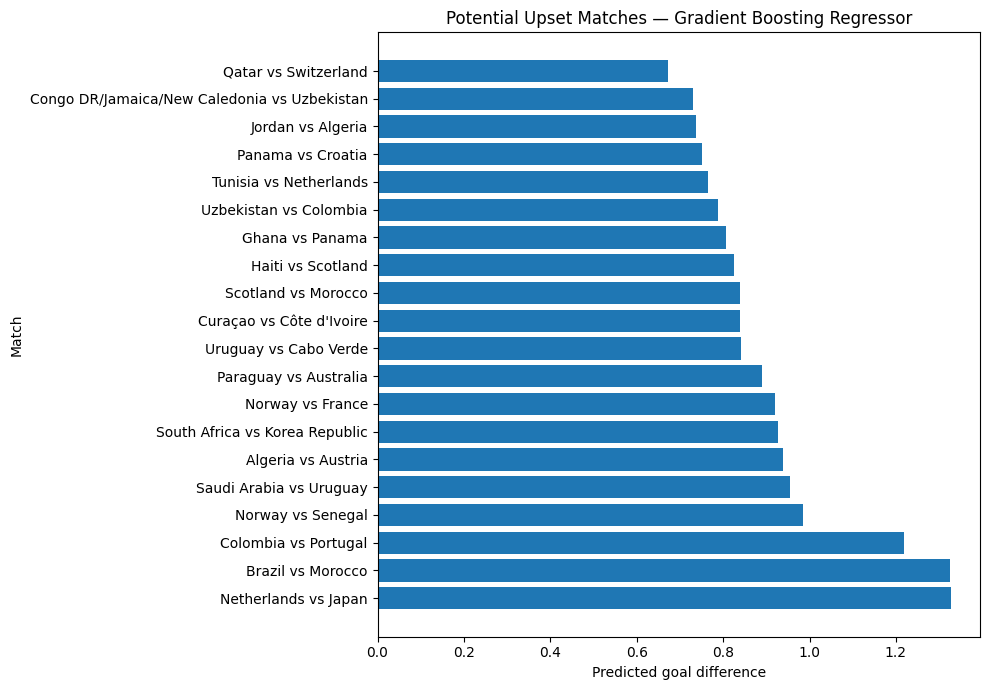

Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\extra_presentation_figures\23_potential_upset_matches.png
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\tables\potential_upset_matches.csv
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\extra_presentation_figures\22_prediction_confidence_matches.png
Saved: C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\ML_Abschlussprojekt_WorldCup2026\output\regression_model_comparison_presentation\tables\worldcup_fixture_prediction_confidence.csv


In [35]:
fixture_feature_path = PROCESSED_DIR / "wc2026_fixture_features.csv"

if fixture_feature_path.exists():
    fixture_features_wc = pd.read_csv(fixture_feature_path)
    fixture_features_wc["date"] = pd.to_datetime(fixture_features_wc["date"], errors="coerce")

    fixture_features_wc = fixture_features_wc[
        fixture_features_wc["group"].notna()
        & fixture_features_wc["group"].astype(str).str.startswith("Group ")
    ].copy()

    fixture_feature_columns = [
        col for col in feature_columns if col in fixture_features_wc.columns
    ]

    fixture_X_wc = fixture_features_wc[fixture_feature_columns].copy()

    best_model_a = trained_models[best_model_name][0]
    best_model_b = trained_models[best_model_name][1]

    pred_a_wc = np.clip(best_model_a.predict(fixture_X_wc), 0, None)
    pred_b_wc = np.clip(best_model_b.predict(fixture_X_wc), 0, None)

    wc_pred = fixture_features_wc[["group", "date", "team_a", "team_b"]].copy()
    wc_pred["pred_team_a_goals"] = pred_a_wc
    wc_pred["pred_team_b_goals"] = pred_b_wc
    wc_pred["predicted_goal_diff_abs"] = np.abs(pred_a_wc - pred_b_wc)
    wc_pred["predicted_total_goals"] = pred_a_wc + pred_b_wc
    wc_pred["confidence_score"] = wc_pred["predicted_goal_diff_abs"]
    wc_pred["favorite"] = np.where(
        fixture_features_wc["points_per_match_diff_last10"] >= 0,
        fixture_features_wc["team_a"],
        fixture_features_wc["team_b"]
    )
    wc_pred["predicted_winner"] = np.where(
        pred_a_wc > pred_b_wc,
        fixture_features_wc["team_a"],
        np.where(pred_a_wc < pred_b_wc, fixture_features_wc["team_b"], "draw")
    )
    wc_pred["upset_candidate"] = (
        (wc_pred["predicted_winner"] != "draw")
        & (wc_pred["predicted_winner"] != wc_pred["favorite"])
    )

    confidence_plot = wc_pred.sort_values("confidence_score", ascending=True).head(20).copy()
    confidence_plot["match"] = confidence_plot["team_a"] + " vs " + confidence_plot["team_b"]

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(confidence_plot["match"], confidence_plot["confidence_score"])
    ax.set_title(f"Prediction Confidence by Match — {best_model_name}")
    ax.set_xlabel("Confidence score |predicted goal difference|")
    ax.set_ylabel("Match")
    fig.tight_layout()
    fig.savefig(EXTRA_FIGURES_DIR / "22_prediction_confidence_matches.png", dpi=150)
    plt.show()

    upset_df = wc_pred[wc_pred["upset_candidate"]].copy()
    if len(upset_df) > 0:
        upset_df = upset_df.sort_values("predicted_goal_diff_abs", ascending=False).head(20)
        upset_df["match"] = upset_df["team_a"] + " vs " + upset_df["team_b"]

        fig, ax = plt.subplots(figsize=(10, 7))
        ax.barh(upset_df["match"], upset_df["predicted_goal_diff_abs"])
        ax.set_title(f"Potential Upset Matches — {best_model_name}")
        ax.set_xlabel("Predicted goal difference")
        ax.set_ylabel("Match")
        fig.tight_layout()
        fig.savefig(EXTRA_FIGURES_DIR / "23_potential_upset_matches.png", dpi=150)
        plt.show()

        upset_df.to_csv(TABLES_DIR / "potential_upset_matches.csv", index=False)
        print("Saved:", EXTRA_FIGURES_DIR / "23_potential_upset_matches.png")
        print("Saved:", TABLES_DIR / "potential_upset_matches.csv")
    else:
        print("No upset candidates were found with the current rule.")

    wc_pred.to_csv(TABLES_DIR / "worldcup_fixture_prediction_confidence.csv", index=False)
    print("Saved:", EXTRA_FIGURES_DIR / "22_prediction_confidence_matches.png")
    print("Saved:", TABLES_DIR / "worldcup_fixture_prediction_confidence.csv")
else:
    print("wc2026_fixture_features.csv was not found. Confidence and upset charts skipped.")



## Extra Presentation Section 9 — Extra Chart Summary

These extra visualizations connect the project more strongly to topics such as dimensionality reduction, clustering, explainability, and tournament-level analysis.


In [37]:
print("Extra presentation figures:")
print(" - 16_team_profile_pca_map_clean.png")
print(" - 17_team_profile_tsne_map_clean.png")
print(" - 18_team_profile_umap_map_clean.png, if UMAP is available")
print(" - 19_team_clustering_kmeans_clean.png")
print(" - 20_team_profile_correlation_heatmap.png")
print(" - 21_group_strength_ranking.png")
print(" - 22_prediction_confidence_matches.png")
print(" - 23_potential_upset_matches.png, if upset candidates exist")

print("\nInteractive HTML figures:")
print(" - 16_team_profile_pca_map_interactive.html")
print(" - 17_team_profile_tsne_map_interactive.html")
print(" - 18_team_profile_umap_map_interactive.html, if UMAP is available")
print(" - 19_team_clustering_kmeans_interactive.html")

print("Extra presentation tables:")
print(" - team_profile_summary.csv")
print(" - team_profile_pca_summary.csv")
print(" - team_cluster_summary.csv")
print(" - team_profile_correlation_matrix.csv")
print(" - group_strength_ranking.csv, if fixture features are available")
print(" - worldcup_fixture_prediction_confidence.csv, if fixture features are available")
print(" - potential_upset_matches.csv, if upset candidates exist")


Extra presentation figures:
 - 16_team_profile_pca_map_clean.png
 - 17_team_profile_tsne_map_clean.png
 - 18_team_profile_umap_map_clean.png, if UMAP is available
 - 19_team_clustering_kmeans_clean.png
 - 20_team_profile_correlation_heatmap.png
 - 21_group_strength_ranking.png
 - 22_prediction_confidence_matches.png
 - 23_potential_upset_matches.png, if upset candidates exist

Interactive HTML figures:
 - 16_team_profile_pca_map_interactive.html
 - 17_team_profile_tsne_map_interactive.html
 - 18_team_profile_umap_map_interactive.html, if UMAP is available
 - 19_team_clustering_kmeans_interactive.html
Extra presentation tables:
 - team_profile_summary.csv
 - team_profile_pca_summary.csv
 - team_cluster_summary.csv
 - team_profile_correlation_matrix.csv
 - group_strength_ranking.csv, if fixture features are available
 - worldcup_fixture_prediction_confidence.csv, if fixture features are available
 - potential_upset_matches.csv, if upset candidates exist


## Final Output Overview

All presentation-ready regression comparison outputs are saved in one separate folder.

In [38]:
print("Tables:")
print(" - output/regression_model_comparison_presentation/tables/goal_regression_model_comparison.csv")
print(" - output/regression_model_comparison_presentation/tables/best_goal_regression_model_summary.csv")
print(" - output/regression_model_comparison_presentation/tables/best_model_test_predictions.csv")
print(" - output/regression_model_comparison_presentation/tables/worst_goal_prediction_errors.csv")
print(" - output/regression_model_comparison_presentation/tables/absolute_goal_error_by_model.csv")
print(" - output/regression_model_comparison_presentation/tables/best_tree_model_feature_importance.csv, if available")
print(" - output/regression_model_comparison_presentation/tables/per_model_plot_summary.csv")
print("\nFigures:")
print(" - 01_total_goals_distribution.png")
print(" - 02_average_goals_per_year.png")
print(" - 03_mae_rmse_model_comparison.png")
print(" - 04_model_ranking_by_mean_mae.png")
print(" - 05_r2_model_comparison.png")
print(" - 06_exact_score_accuracy.png")
print(" - 07_outcome_accuracy_from_scores.png")
print(" - 08_total_goals_mae_by_model.png")
print(" - 09_actual_vs_predicted_team_a.png")
print(" - 10_actual_vs_predicted_team_b.png")
print(" - 11_actual_vs_predicted_total_goals.png")
print(" - 12_goal_prediction_residuals.png")
print(" - 13_absolute_goal_error_boxplot.png")
print(" - 14_largest_goal_prediction_errors.png")
print(" - 15_best_model_feature_importance.png, if available")
print(" - figures_per_model/<model_name>/... separate charts for every model")
print("\nModels:")
print(" - output/regression_model_comparison_presentation/models/best_comparison_team_a_goals_model.joblib")
print(" - output/regression_model_comparison_presentation/models/best_comparison_team_b_goals_model.joblib")
print("\nPresentation-ready goal regression comparison completed.")

print("\nExtra figures folder:")
print(" - output/regression_model_comparison_presentation/extra_presentation_figures/...")



Tables:
 - output/regression_model_comparison_presentation/tables/goal_regression_model_comparison.csv
 - output/regression_model_comparison_presentation/tables/best_goal_regression_model_summary.csv
 - output/regression_model_comparison_presentation/tables/best_model_test_predictions.csv
 - output/regression_model_comparison_presentation/tables/worst_goal_prediction_errors.csv
 - output/regression_model_comparison_presentation/tables/absolute_goal_error_by_model.csv
 - output/regression_model_comparison_presentation/tables/best_tree_model_feature_importance.csv, if available
 - output/regression_model_comparison_presentation/tables/per_model_plot_summary.csv

Figures:
 - 01_total_goals_distribution.png
 - 02_average_goals_per_year.png
 - 03_mae_rmse_model_comparison.png
 - 04_model_ranking_by_mean_mae.png
 - 05_r2_model_comparison.png
 - 06_exact_score_accuracy.png
 - 07_outcome_accuracy_from_scores.png
 - 08_total_goals_mae_by_model.png
 - 09_actual_vs_predicted_team_a.png
 - 10_actu